## Generazione dataset sintetico

In [1]:
import pandas as pd

import numpy as np

from datetime import datetime, timedelta


# Generazione date (ultimi 30 giorni)

dates = pd.date_range(end=datetime.today(), periods=24*30, freq='h')


# Dataset Produzione Solare (con qualche dato sporco/nullo)

production = np.maximum(0, np.sin((dates.hour.to_numpy() - 6) * np.pi / 12) * 5 + np.random.normal(0, 0.5, len(dates)))

production[dates.hour < 6] = 0 # Notte

production[dates.hour > 20] = 0 # Notte

df_prod = pd.DataFrame({'timestamp': dates, 'kwh_produced': production})



# Introduciamo anomalie (dati sporchi)

df_prod.loc[100:105, 'kwh_produced'] = np.nan # Sensore rotto

df_prod.loc[200, 'kwh_produced'] = -5 # Errore sensore (valore negativo impossibile)


# Dataset Consumi Utente

consumption = np.random.normal(1.5, 0.5, len(dates)) # Consumo base

consumption[dates.hour.isin([19, 20, 21])] += 2 # Picco serale

df_cons = pd.DataFrame({'timestamp': dates, 'kwh_consumed': consumption})


# Salvataggio

df_prod.to_csv("solar_production_raw.csv", index=False)

df_cons.to_csv("household_consumption.csv", index=False)


print("Dataset generati: 'solar_production_raw.csv' e 'household_consumption.csv'")

Dataset generati: 'solar_production_raw.csv' e 'household_consumption.csv'


In [2]:
#per capire la struttura dei dataset
import pandas as pd

df_prod = pd.read_csv("solar_production_raw.csv")
df_cons = pd.read_csv("household_consumption.csv")

print("=== Produzione solare (df_prod) ===")
df_prod.info()
print()
print(df_prod.head())
print()
print(df_prod.describe())
print()
print("Valori NaN:", df_prod['kwh_produced'].isna().sum())
print("Valori negativi:", (df_prod['kwh_produced'] < 0).sum())

print("\n\n=== Consumo domestico (df_cons) ===")
df_cons.info()
print()
print(df_cons.head())
print()
print(df_cons.describe())
print()
print("Valori NaN:", df_cons['kwh_consumed'].isna().sum())
print("Valori negativi:", (df_cons['kwh_consumed'] < 0).sum())

=== Produzione solare (df_prod) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     720 non-null    object 
 1   kwh_produced  714 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.4+ KB

                    timestamp  kwh_produced
0  2026-08-03 11:56:51.631923      4.463392
1  2026-08-03 12:56:51.631923      5.366820
2  2026-08-03 13:56:51.631923      4.161311
3  2026-08-03 14:56:51.631923      3.076579
4  2026-08-03 15:56:51.631923      3.433847

       kwh_produced
count    714.000000
mean       1.594040
std        1.979719
min       -5.000000
25%        0.000000
50%        0.029146
75%        3.513435
max        6.413309

Valori NaN: 6
Valori negativi: 1


=== Consumo domestico (df_cons) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 2 columns):
 #   Column  

In [3]:
#installazione Librerie
!pip install langchain langchain-openai streamlit python-dotenv matplotlib seaborn requests

In [4]:
#Setup, caricamento sicuro della API key dal file .env
import os
from dotenv import load_dotenv

load_dotenv() #serve per legger il file .env

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY non trovato. Crea un file .env nella cartella del progetto "
        "con la riga: OPENAI_API_KEY=la_tua_chiave"
    )

print("API key caricata correttamente")

API key caricata correttamente


## Architetura dei tool

In [5]:
# Data store condiviso, qui andranno i due dataset puliti che i vari tool useranno
import pandas as pd
from dataclasses import dataclass, field

@dataclass
class DatiEcoBot:
    """Contenitore dei dati puliti su cui operano i tool dell'agente."""
    produzione: pd.DataFrame = None #colonne: timestamp, kwh_produced
    consumo: pd.DataFrame = None # colonne: timestamp, kwh_consumed
    log_pulizia: list = field(default_factory=list) #contiene i messaggi leggibili sulle anomalie trovate/corrette

#istanza unica usata da tutti i tool nel notebook
dati = DatiEcoBot()

print("Data store creato:", dati)

Data store creato: DatiEcoBot(produzione=None, consumo=None, log_pulizia=[])


In [6]:
# motore di pulizia: corregge NaN, valori negativi impossibili, timestamp duplicati/mancanti
def _pulisci_serie(df: pd.DataFrame, colonna_valore: str, nome_dataset: str) -> tuple[pd.DataFrame, list[str]]:
    """Pulisce una singola serie temporale (produzione o consumo).
    Ritorna il dataframe pulito e la lista di messaggi leggibili sulle anomalie trovate."""
    messaggi = []
    df = df.copy()

    # timestamp: parsing, ordinamento, rimozione duplivati
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    duplicati = df["timestamp"].duplicated().sum()
    if duplicati > 0:
        df = df.drop_duplicates(subset="timestamp", keep="first")
        messaggi.append(f"[{nome_dataset}] Rimossi {duplicati} timestamp duplicati.")
    df = df.sort_values("timestamp").reset_index(drop=True)

    # valori mancanti: interpolazione lineare(probabile guasto sensore)
    n_nan = df[colonna_valore].isna().sum()
    if n_nan > 0:
        df[colonna_valore] = df[colonna_valore].interpolate(method="linear", limit_direction="both")
        messaggi.append(f"[{nome_dataset}] Interpolati {n_nan} valori mancanti (probabile guasto sensore).")

    #valori negativi impossibili: portati a 0
    n_negativi = (df[colonna_valore] < 0).sum()
    if n_negativi > 0:
        df.loc[df[colonna_valore] < 0, colonna_valore] = 0.0
        messaggi.append(f"[{nome_dataset}] Corretti {n_negativi} valori negativi impossibili (portati a 0).")

    # buchi temporali: solo segnalazione, nessuna correzione automatica
    if len(df) > 1:
        attesi = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
        mancanti = attesi.difference(df["timestamp"])
        if len(mancanti) > 0:
            messaggi.append(f"[{nome_dataset}] Rilevati {len(mancanti)} intervalli orari mancanti nella serie.")

    if not messaggi:
        messaggi.append(f"[{nome_dataset}] Nessuna anomalia rilevata.")

    return df, messaggi

## Tools

In [7]:
from langchain.tools import tool

#factory
def crea_tool_pulizia(dati: DatiEcoBot, path_produzione: str, path_consumo: str):
    """Factory: crea il tool di pulizia legato a un'istanza di DatiEcoBot e ai percorsi dei due CSV."""

    @tool
    def pulisci_dati() -> str:
        """Carica i CSV di produzione solare e consumo domestico, individua e corregge automaticamente
        le anomalie tipiche dei sensori IoT (valori mancanti, valori negativi impossibili, timestamp
        duplicati o mancanti), e aggiorna il data store con i dataset puliti. Va chiamato come primo
        passo prima di qualsiasi analisi se i dati non sono ancora stati caricati."""
        df_prod_raw = pd.read_csv(path_produzione)
        df_cons_raw = pd.read_csv(path_consumo)

        dati.produzione, msg_prod = _pulisci_serie(df_prod_raw, "kwh_produced", "produzione")
        dati.consumo, msg_cons = _pulisci_serie(df_cons_raw, "kwh_consumed", "consumo")
        dati.log_pulizia = msg_prod + msg_cons

        return "Dati caricati e puliti con successo.\n" + "\n".join(dati.log_pulizia)

    return pulisci_dati

# Istanza del tool, agganciata ai due CSV nella cartella del progetto
tool_pulisci_dati = crea_tool_pulizia(dati, "solar_production_raw.csv", "household_consumption.csv")

In [8]:
#  test diretto del tool (senza agente , solo per verificare che funzioni)
risultato = tool_pulisci_dati.invoke({})
print(risultato)
print()
print(dati.produzione.loc[95:110])   # controlliamo che i NaN siano stati interpolati

Dati caricati e puliti con successo.
[produzione] Interpolati 6 valori mancanti (probabile guasto sensore).
[produzione] Corretti 1 valori negativi impossibili (portati a 0).
[consumo] Corretti 3 valori negativi impossibili (portati a 0).

                     timestamp  kwh_produced
95  2026-08-07 10:56:51.631923      3.835094
96  2026-08-07 11:56:51.631923      5.390110
97  2026-08-07 12:56:51.631923      4.855864
98  2026-08-07 13:56:51.631923      4.637873
99  2026-08-07 14:56:51.631923      5.427870
100 2026-08-07 15:56:51.631923      4.652460
101 2026-08-07 16:56:51.631923      3.877050
102 2026-08-07 17:56:51.631923      3.101640
103 2026-08-07 18:56:51.631923      2.326230
104 2026-08-07 19:56:51.631923      1.550820
105 2026-08-07 20:56:51.631923      0.775410
106 2026-08-07 21:56:51.631923      0.000000
107 2026-08-07 22:56:51.631923      0.000000
108 2026-08-07 23:56:51.631923      0.000000
109 2026-08-08 00:56:51.631923      0.000000
110 2026-08-08 01:56:51.631923      0.00

In [9]:
#helper condiviso : filtra un dataframe oer intervallo di date(entrmbi i parametri opzionali)
#funziona riutilizzabile da altri tool
def _filtra_periodo(df: pd.DataFrame, data_inizio: str = None, data_fine: str = None) -> pd.DataFrame:
    """Filtra un dataframe con colonna 'timestamp' in base a un intervallo di date (formato 'YYYY-MM-DD')."""
    if data_inizio:
        df = df[df["timestamp"] >= pd.to_datetime(data_inizio)]
    if data_fine:
        df = df[df["timestamp"] < pd.to_datetime(data_fine) + pd.Timedelta(days=1)]  # include intera giornata finale
    return df

In [10]:
def crea_tool_produzione(dati: DatiEcoBot):
    @tool
    def calcola_produzione(data_inizio: str = "", data_fine: str = "") -> str:
        """Calcola l'energia solare totale prodotta dall'azienda in un intervallo di date.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (vuota = dall'inizio dei dati disponibili).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (vuota = fino alla fine dei dati disponibili).
        """
        if dati.produzione is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."
        df = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        if df.empty:
            return "Nessun dato di produzione nel periodo richiesto."
        totale = df["kwh_produced"].sum()
        media_oraria = df["kwh_produced"].mean()
        return (
            f"Produzione totale: {totale:.2f} kWh su {len(df)} ore "
            f"({df['timestamp'].min().date()} - {df['timestamp'].max().date()}), "
            f"media oraria {media_oraria:.2f} kWh."
        )
    return calcola_produzione


def crea_tool_consumo(dati: DatiEcoBot):
    @tool
    def calcola_consumo(data_inizio: str = "", data_fine: str = "") -> str:
        """Calcola l'energia totale consumata dalla famiglia in un intervallo di date.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (vuota = dall'inizio dei dati disponibili).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (vuota = fino alla fine dei dati disponibili).
        """
        if dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."
        df = _filtra_periodo(dati.consumo, data_inizio or None, data_fine or None)
        if df.empty:
            return "Nessun dato di consumo nel periodo richiesto."
        totale = df["kwh_consumed"].sum()
        media_oraria = df["kwh_consumed"].mean()
        return (
            f"Consumo totale: {totale:.2f} kWh su {len(df)} ore "
            f"({df['timestamp'].min().date()} - {df['timestamp'].max().date()}), "
            f"media oraria {media_oraria:.2f} kWh."
        )
    return calcola_consumo

In [11]:
def crea_tool_confronto(dati: DatiEcoBot):
    @tool
    def confronta_produzione_consumo(data_inizio: str = "", data_fine: str = "") -> str:
        """Confronta l'energia prodotta con quella consumata in un intervallo di date: dice se c'è
        surplus (energia in eccesso) o deficit, e indica il giorno con il maggior surplus.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        prod = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        cons = _filtra_periodo(dati.consumo, data_inizio or None, data_fine or None)
        merged = pd.merge(prod, cons, on="timestamp", how="inner")
        if merged.empty:
            return "Nessun dato disponibile nel periodo richiesto."

        totale_prod = merged["kwh_produced"].sum()
        totale_cons = merged["kwh_consumed"].sum()
        bilancio = totale_prod - totale_cons

        merged["giorno"] = merged["timestamp"].dt.date
        giornaliero = merged.groupby("giorno").agg(
            prodotto=("kwh_produced", "sum"), consumato=("kwh_consumed", "sum")
        )
        giornaliero["surplus"] = giornaliero["prodotto"] - giornaliero["consumato"]
        giorno_top = giornaliero["surplus"].idxmax()

        esito = "surplus (energia in eccesso)" if bilancio >= 0 else "deficit (consumato più di quanto prodotto)"
        return (
            f"Nel periodo: prodotto {totale_prod:.2f} kWh, consumato {totale_cons:.2f} kWh -> {esito} "
            f"di {abs(bilancio):.2f} kWh. Giorno con il maggior surplus: {giorno_top} "
            f"({giornaliero.loc[giorno_top, 'surplus']:.2f} kWh in eccesso)."
        )
    return confronta_produzione_consumo

In [12]:
#tool crea_tool_andamento_orario riutilizzabile
def crea_tool_andamento_orario(dati: DatiEcoBot):
    @tool
    def andamento_orario(serie: str, data_inizio: str = "", data_fine: str = "") -> str:
        """Calcola il valore medio per ogni ora del giorno (0-23) di produzione o consumo, utile per
        capire in quali fasce orarie si consuma o produce di più.
        Args:
            serie: 'produzione' oppure 'consumo'.
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        if serie == "produzione":
            df, colonna = dati.produzione, "kwh_produced"
        elif serie == "consumo":
            df, colonna = dati.consumo, "kwh_consumed"
        else:
            return "Valore 'serie' non valido: usa 'produzione' o 'consumo'."

        df = _filtra_periodo(df, data_inizio or None, data_fine or None)
        if df.empty:
            return "Nessun dato nel periodo richiesto."

        medie_orarie = df.groupby(df["timestamp"].dt.hour)[colonna].mean().round(2)
        ora_picco = medie_orarie.idxmax()
        righe = [f"{ora}:00 -> {valore:.2f} kWh medi" for ora, valore in medie_orarie.items()]
        return (
            f"Andamento orario medio di {serie}:\n" + "\n".join(righe) +
            f"\n\nOra con il valore più alto: {ora_picco}:00 ({medie_orarie[ora_picco]:.2f} kWh medi)."
        )
    return andamento_orario


def crea_tool_anomalie(dati: DatiEcoBot):
    @tool
    def individua_anomalie() -> str:
        """Riporta le anomalie rilevate durante la pulizia dei dati (es. guasti ai sensori, valori
        mancanti, valori impossibili corretti). Usalo per rispondere a domande come 'c'è stato un
        guasto ai sensori?'."""
        if not dati.log_pulizia:
            return "Nessuna pulizia dati ancora eseguita: chiama prima il tool pulisci_dati."
        return "Anomalie rilevate durante la pulizia dei dati:\n" + "\n".join(dati.log_pulizia)
    return individua_anomalie

In [13]:
def crea_tool_kpi_energetici(dati: DatiEcoBot):
    @tool
    def calcola_kpi_energetici(data_inizio: str = "", data_fine: str = "") -> str:
        """Calcola i principali indicatori di performance (KPI) energetici in un intervallo di date:
        indice di autoconsumo, indice di autosufficienza e percentuale di surplus ceduto alla rete.
        Usalo per rispondere a domande su quanto viene "autoconsumato" o condiviso con la comunità
        energetica, non solo su totali semplici di produzione/consumo.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        prod = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        cons = _filtra_periodo(dati.consumo, data_inizio or None, data_fine or None)
        merged = pd.merge(prod, cons, on="timestamp", how="inner")
        if merged.empty:
            return "Nessun dato disponibile nel periodo richiesto."

        totale_prod = merged["kwh_produced"].sum()
        totale_cons = merged["kwh_consumed"].sum()

        # energia autoconsumata ogni ora = il minimo tra prodotto e consumato in quell'ora
        # (l'energia in eccesso rispetto al consumo va invece in surplus/condivisione)
        autoconsumo_orario = merged[["kwh_produced", "kwh_consumed"]].min(axis=1)
        energia_autoconsumata = autoconsumo_orario.sum()

        indice_autoconsumo = (energia_autoconsumata / totale_prod * 100) if totale_prod > 0 else 0.0
        indice_autosufficienza = (energia_autoconsumata / totale_cons * 100) if totale_cons > 0 else 0.0
        surplus_ceduto = totale_prod - energia_autoconsumata
        percentuale_surplus = (surplus_ceduto / totale_prod * 100) if totale_prod > 0 else 0.0

        return (
            f"KPI energetici nel periodo ({merged['timestamp'].min().date()} - {merged['timestamp'].max().date()}):\n"
            f"- Indice di autoconsumo: {indice_autoconsumo:.1f}% "
            f"(quota della produzione usata direttamente sul posto: {energia_autoconsumata:.2f} kWh su {totale_prod:.2f} kWh prodotti).\n"
            f"- Indice di autosufficienza: {indice_autosufficienza:.1f}% "
            f"(quota del consumo coperta dalla produzione propria, su {totale_cons:.2f} kWh consumati).\n"
            f"- Surplus ceduto alla rete/comunità: {surplus_ceduto:.2f} kWh ({percentuale_surplus:.1f}% della produzione totale)."
        )
    return calcola_kpi_energetici

In [14]:
#fattore di emissione medio della rete elettrica italiana: 0,216 kg CO2/kWh
# (fonte: ISPRA, dato 2023 sulla produzione elettrica nazionale lorda - valore indicativo/ approssimativo,
# non un dato aggiornato in tempo reale)
FATTORE_EMISSIONE_CO2_KWH = 0.216


def crea_tool_co2(dati: DatiEcoBot):
    @tool
    def co2_risparmiata(data_inizio: str = "", data_fine: str = "") -> str:
        """Stima la CO2 evitata grazie all'energia rinnovabile prodotta in un intervallo di date,
        rispetto a se quella stessa energia fosse stata prelevata dalla rete elettrica tradizionale
        (mix medio italiano). Considera tutta l'energia prodotta, non solo quella autoconsumata, perché
        anche il surplus condiviso con la comunità energetica evita emissioni altrove nella rete.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."
        prod = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        if prod.empty:
            return "Nessun dato di produzione nel periodo richiesto."

        totale_prod = prod["kwh_produced"].sum()
        co2_evitata_kg = totale_prod * FATTORE_EMISSIONE_CO2_KWH

        return (
            f"Nel periodo, la produzione di {totale_prod:.2f} kWh di energia rinnovabile ha evitato "
            f"circa {co2_evitata_kg:.1f} kg di CO2 rispetto all'uso della rete elettrica tradizionale "
            f"(stima basata su un fattore medio di {FATTORE_EMISSIONE_CO2_KWH} kg CO2/kWh, fonte ISPRA)."
        )
    return co2_risparmiata

In [15]:
def _indice_autoconsumo_periodo(dati: DatiEcoBot, data_inizio, data_fine):
    """Restituisce l'indice di autoconsumo (%) nel periodo indicato (date pandas/Timestamp),
    o None se non ci sono abbastanza dati nel periodo. Riusa _filtra_periodo, stessa logica
    di calcolo già usata da calcola_kpi_energetici."""
    prod = _filtra_periodo(dati.produzione, data_inizio.strftime("%Y-%m-%d"), data_fine.strftime("%Y-%m-%d"))
    cons = _filtra_periodo(dati.consumo, data_inizio.strftime("%Y-%m-%d"), data_fine.strftime("%Y-%m-%d"))
    merged = pd.merge(prod, cons, on="timestamp", how="inner")
    if merged.empty:
        return None
    totale_prod = merged["kwh_produced"].sum()
    if totale_prod <= 0:
        return None
    autoconsumo_orario = merged[["kwh_produced", "kwh_consumed"]].min(axis=1)
    energia_autoconsumata = autoconsumo_orario.sum()
    return energia_autoconsumata / totale_prod * 100


def crea_tool_eco_score(dati: DatiEcoBot):
    @tool
    def punteggio_eco_settimanale() -> str:
        """
        Confronta l'indice di autoconsumo degli ultimi 7 giorni disponibili nei dati con
        quello dei 7 giorni precedenti, per mostrare il progresso settimana su settimana
        (una sorta di "eco score"). Usalo per domande tipo "come sto andando questa
        settimana?", "sono migliorato rispetto alla settimana scorsa?" o "dammi il mio
        punteggio eco".
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        ultimo_timestamp = max(dati.produzione["timestamp"].max(), dati.consumo["timestamp"].max())
        fine_corrente = ultimo_timestamp.normalize()
        inizio_corrente = fine_corrente - pd.Timedelta(days=6)
        fine_precedente = inizio_corrente - pd.Timedelta(days=1)
        inizio_precedente = fine_precedente - pd.Timedelta(days=6)

        autoconsumo_corrente = _indice_autoconsumo_periodo(dati, inizio_corrente, fine_corrente)
        autoconsumo_precedente = _indice_autoconsumo_periodo(dati, inizio_precedente, fine_precedente)

        if autoconsumo_corrente is None or autoconsumo_precedente is None:
            return "Non ci sono abbastanza dati storici (servono almeno 14 giorni) per calcolare un confronto settimana su settimana."

        differenza = autoconsumo_corrente - autoconsumo_precedente

        if differenza > 0.5:
            return (
                f"Ottimo lavoro! Questa settimana sei salito al {autoconsumo_corrente:.0f}% di "
                f"autoconsumo, rispetto al {autoconsumo_precedente:.0f}% della settimana precedente."
            )
        elif differenza < -0.5:
            return (
                f"Questa settimana l'autoconsumo è sceso al {autoconsumo_corrente:.0f}% "
                f"(era {autoconsumo_precedente:.0f}% la settimana scorsa). Prova a spostare qualche "
                f"consumo nelle ore di maggior produzione solare per recuperare terreno."
            )
        else:
            return (
                f"Questa settimana l'autoconsumo è stabile al {autoconsumo_corrente:.0f}%, "
                f"in linea con la settimana precedente."
            )

    return punteggio_eco_settimanale

In [16]:
#istanze tools
tool_produzione = crea_tool_produzione(dati)
tool_consumo = crea_tool_consumo(dati)
tool_confronto = crea_tool_confronto(dati)
tool_andamento_orario = crea_tool_andamento_orario(dati)
tool_anomalie = crea_tool_anomalie(dati)
tool_kpi = crea_tool_kpi_energetici(dati)
tool_co2 = crea_tool_co2(dati)
tool_eco_score = crea_tool_eco_score(dati)

In [17]:
#testing

print(tool_produzione.invoke({"data_inizio": "", "data_fine": ""}))
print()
print("------------------------------------")
print()
print(tool_confronto.invoke({"data_inizio": "", "data_fine": ""}))
print()
print("------------------------------------")
print()
print(tool_andamento_orario.invoke({"serie": "consumo"}))
print()
print("------------------------------------")
print()
print(tool_anomalie.invoke({}))
print()
print("------------------------------------")
print()
print(tool_kpi.invoke({"data_inizio": "", "data_fine": ""}))
print()
print("------------------------------------")
print()
print(tool_co2.invoke({"data_inizio": "", "data_fine": ""}))
print()
print("------------------------------------")
print()
print(tool_eco_score.invoke({}))

Produzione totale: 1159.43 kWh su 720 ore (2026-08-03 - 2026-09-02), media oraria 1.61 kWh.

------------------------------------

Nel periodo: prodotto 1159.43 kWh, consumato 1273.62 kWh -> deficit (consumato più di quanto prodotto) di 114.19 kWh. Giorno con il maggior surplus: 2026-08-07 (7.46 kWh in eccesso).

------------------------------------

Andamento orario medio di consumo:
0:00 -> 1.45 kWh medi
1:00 -> 1.53 kWh medi
2:00 -> 1.59 kWh medi
3:00 -> 1.50 kWh medi
4:00 -> 1.44 kWh medi
5:00 -> 1.57 kWh medi
6:00 -> 1.41 kWh medi
7:00 -> 1.54 kWh medi
8:00 -> 1.45 kWh medi
9:00 -> 1.51 kWh medi
10:00 -> 1.55 kWh medi
11:00 -> 1.51 kWh medi
12:00 -> 1.49 kWh medi
13:00 -> 1.58 kWh medi
14:00 -> 1.51 kWh medi
15:00 -> 1.64 kWh medi
16:00 -> 1.39 kWh medi
17:00 -> 1.50 kWh medi
18:00 -> 1.44 kWh medi
19:00 -> 3.55 kWh medi
20:00 -> 3.50 kWh medi
21:00 -> 3.55 kWh medi
22:00 -> 1.68 kWh medi
23:00 -> 1.54 kWh medi

Ora con il valore più alto: 19:00 (3.55 kWh medi).

-----------------

In [18]:
#grafici

In [19]:
import os
from datetime import datetime
import matplotlib
matplotlib.use("Agg")  #necessario perché l'app Streamlit non ha un display grafico
import matplotlib.pyplot as plt

CARTELLA_GRAFICI = "grafici"
os.makedirs(CARTELLA_GRAFICI, exist_ok=True)

In [20]:
def crea_tool_grafico(dati: DatiEcoBot):
    @tool
    def genera_grafico(tipo: str, data_inizio: str = "", data_fine: str = "") -> str:
        """Genera e salva come immagine PNG un grafico per visualizzare l'andamento energetico.
        Da usare quando l'utente chiede esplicitamente un grafico, un andamento visivo o una curva.
        Args:
            tipo: tipo di grafico, uno tra:
                'produzione' (curva della produzione nel tempo),
                'consumo' (curva del consumo nel tempo),
                'confronto' (produzione e consumo sovrapposti nel tempo),
                'andamento_orario_produzione' (produzione media per ora del giorno),
                'andamento_orario_consumo' (consumo medio per ora del giorno).
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """

        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        prod = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        cons = _filtra_periodo(dati.consumo, data_inizio or None, data_fine or None)

        fig, ax = plt.subplots(figsize=(10, 5))

        if tipo == "produzione":
            ax.plot(prod["timestamp"], prod["kwh_produced"], color="#f5a623")
            ax.set_title("Produzione solare nel tempo")
            ax.set_xlabel("Data e ora")
            ax.set_ylabel("kWh prodotti")
            fig.autofmt_xdate()

        elif tipo == "consumo":
            ax.plot(cons["timestamp"], cons["kwh_consumed"], color="#4a90d9")
            ax.set_title("Consumo domestico nel tempo")
            ax.set_xlabel("Data e ora")
            ax.set_ylabel("kWh consumati")
            fig.autofmt_xdate()

        elif tipo == "confronto":
            ax.plot(prod["timestamp"], prod["kwh_produced"], label="Produzione", color="#f5a623")
            ax.plot(cons["timestamp"], cons["kwh_consumed"], label="Consumo", color="#4a90d9")
            ax.set_title("Produzione vs Consumo")
            ax.set_xlabel("Data e ora")
            ax.set_ylabel("kWh")
            ax.legend()
            fig.autofmt_xdate()

        elif tipo == "andamento_orario_produzione":
            medie = prod.groupby(prod["timestamp"].dt.hour)["kwh_produced"].mean()
            ax.bar(medie.index, medie.values, color="#f5a623")
            ax.set_title("Produzione media per ora del giorno")
            ax.set_xlabel("Ora del giorno")
            ax.set_ylabel("kWh medi")
            ax.set_xticks(range(0, 24, 2))

        elif tipo == "andamento_orario_consumo":
            medie = cons.groupby(cons["timestamp"].dt.hour)["kwh_consumed"].mean()
            ax.bar(medie.index, medie.values, color="#4a90d9")
            ax.set_title("Consumo medio per ora del giorno")
            ax.set_xlabel("Ora del giorno")
            ax.set_ylabel("kWh medi")
            ax.set_xticks(range(0, 24, 2))

        else:
            plt.close(fig)
            return (
                "Tipo di grafico non valido. Usa uno tra: 'produzione', 'consumo', 'confronto', "
                "'andamento_orario_produzione', 'andamento_orario_consumo'."
            )

        fig.tight_layout()

        timestamp_file = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        nome_file = f"{tipo}_{timestamp_file}.png"
        percorso = os.path.join(CARTELLA_GRAFICI, nome_file)
        fig.savefig(percorso, dpi=120)
        plt.close(fig)

        dati.grafici_generati.append(percorso)
        return f"Grafico generato e salvato in: {percorso}"

    return genera_grafico

In [21]:
dati.grafici_generati = []  # elenco dei percorsi dei grafici generati in questa sessione
tool_grafico = crea_tool_grafico(dati)

Grafico generato e salvato in: grafici/confronto_20260902_105653_474858.png


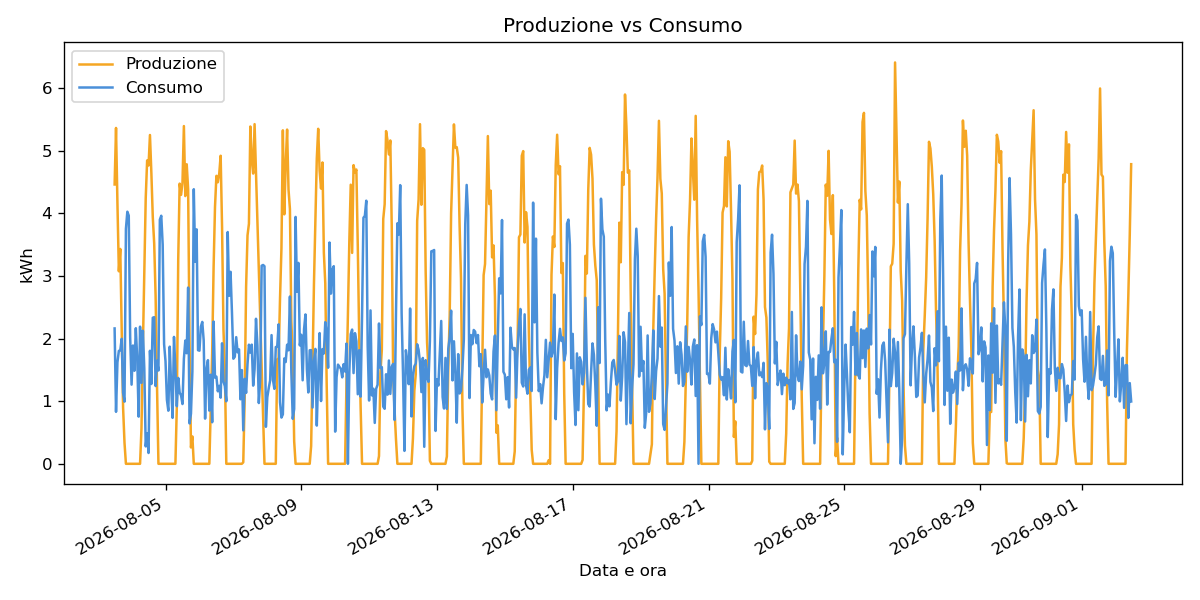

In [22]:
from IPython.display import Image, display

risultato = tool_grafico.invoke({"tipo": "confronto", "data_inizio": "", "data_fine": ""})
print(risultato)

display(Image(filename=dati.grafici_generati[-1]))

## Tool esterno: previsione meteo

In [23]:
import requests
from datetime import date as _date


def geocodifica_citta(nome_citta: str) -> dict:
    """Converte il nome di una città in coordinate geografiche (lat/lon) usando l'API di geocoding
    gratuita di Open-Meteo. Ritorna un dizionario {'nome', 'lat', 'lon'}, oppure None se la città
    non viene trovata o l'API non risponde."""
    try:
        risposta = requests.get(
            "https://geocoding-api.open-meteo.com/v1/search",
            params={"name": nome_citta, "count": 1, "language": "it"},
            timeout=10,
        )
        risposta.raise_for_status()
        risultati = risposta.json().get("results")
        if not risultati:
            return None
        primo = risultati[0]
        return {"nome": primo["name"], "lat": primo["latitude"], "lon": primo["longitude"]}
    except Exception:
        return None


def crea_tool_meteo(localita: dict):
    """Factory: crea il tool di previsione meteo legato a una specifica località (lat/lon).
    Passare la località dall'esterno invece di usare una costante globale evita che, in Streamlit,
    la città scelta da un utente influenzi le previsioni mostrate a un altro utente."""
    @tool
    def previsione_meteo(giorni: int = 3) -> str:
        """Restituisce le previsioni meteo (temperatura, radiazione solare attesa, probabilità di pioggia)
        per i prossimi giorni nella località dell'utente, con etichetta "oggi/domani/dopodomani/tra N
        giorni" per ogni giornata. Usalo per consigli proattivi su quando conviene usare elettrodomestici,
        o per stimare quanto varierà la produzione solare nei giorni a venire (i CSV contengono solo dati
        storici passati, quindi per parlare del futuro serve questo tool).
        Args:
            giorni: quante giornate restituire A PARTIRE DA OGGI incluso (il primo giorno restituito è
                sempre oggi), da 1 a 7. Es. per rispondere su "domani" chiedi almeno giorni=2, così la
                risposta includerà anche la voce etichettata "domani".
        """
        giorni = max(1, min(giorni, 7))
        try:
            risposta = requests.get(
                "https://api.open-meteo.com/v1/forecast",
                params={
                    "latitude": localita["lat"],
                    "longitude": localita["lon"],
                    "daily": "temperature_2m_max,temperature_2m_min,shortwave_radiation_sum,precipitation_probability_max",
                    "timezone": "Europe/Rome",
                    "forecast_days": giorni,
                },
                timeout=10,
            )
            risposta.raise_for_status()
            dati_meteo = risposta.json()["daily"]
        except Exception as errore:
            return (
                f"Impossibile recuperare le previsioni meteo al momento ({errore}). "
                "Rispondi comunque basandoti sui dati storici disponibili, senza inventare un meteo futuro."
            )

        oggi = _date.today()
        etichette_relative = {0: "oggi", 1: "domani", 2: "dopodomani"}

        righe = []
        for i, giorno in enumerate(dati_meteo["time"]):
            scarto = (_date.fromisoformat(giorno) - oggi).days
            etichetta = etichette_relative.get(scarto, f"tra {scarto} giorni")
            righe.append(
                f"{etichetta} ({giorno}): {dati_meteo['temperature_2m_min'][i]:.0f}-{dati_meteo['temperature_2m_max'][i]:.0f}°C, "
                f"radiazione solare attesa {dati_meteo['shortwave_radiation_sum'][i]:.1f} MJ/m², "
                f"probabilità pioggia {dati_meteo['precipitation_probability_max'][i]:.0f}%"
            )

        return (
            f"Previsioni meteo per {localita['nome']}:\n" + "\n".join(righe) +
            "\n\nRadiazione solare più alta = giornata più soleggiata, aspettati più produzione fotovoltaica; "
            "radiazione bassa (giornata nuvolosa/piovosa) = produzione ridotta."
        )

    return previsione_meteo

In [24]:
# test tool esterno di previsione meteo
# in questa fase di test nel notebook usiamo Roma come città fissa;
# in Streamlit sarà l'utente a scegliere la propria città
localita_test = geocodifica_citta("Roma") or {"nome": "Roma", "lat": 41.9028, "lon": 12.4964}
tool_meteo = crea_tool_meteo(localita_test)

print("Località trovata:", localita_test)
print()
print(tool_meteo.invoke({"giorni": 3}))

Località trovata: {'nome': 'Roma', 'lat': 41.89193, 'lon': 12.51133}

Previsioni meteo per Roma:
oggi (2026-09-02): 22-35°C, radiazione solare attesa 21.3 MJ/m², probabilità pioggia 0%
domani (2026-09-03): 20-34°C, radiazione solare attesa 21.5 MJ/m², probabilità pioggia 0%
dopodomani (2026-09-04): 21-35°C, radiazione solare attesa 21.2 MJ/m², probabilità pioggia 0%

Radiazione solare più alta = giornata più soleggiata, aspettati più produzione fotovoltaica; radiazione bassa (giornata nuvolosa/piovosa) = produzione ridotta.


## Tool esterno: previsione produzione (Forecast.Solar)

In [25]:
#import gia usati prima
def _richiedi_produzione_forecast(config_impianto):
    """Interroga Forecast.Solar e ritorna una tupla (dati, errore):
    - in caso di successo: (dict {data 'YYYY-MM-DD': wh prodotti quel giorno}, None)
    - in caso di errore di rete/HTTP: (None, messaggio di errore descrittivo)
    - in caso di risposta senza dati validi: (None, None)
    Condivisa dal tool conversazionale previsione_produzione e dal generatore di missioni giornaliere,
    per non duplicare la chiamata all'API esterna in due punti diversi."""
    lat = config_impianto["lat"]
    lon = config_impianto["lon"]
    dec = config_impianto.get("dec", 30)
    az = config_impianto.get("az", 0)
    kwp = config_impianto["kwp"]

    url = f"https://api.forecast.solar/estimate/{lat}/{lon}/{dec}/{az}/{kwp}"

    try:
        risposta = requests.get(url, timeout=10)
        risposta.raise_for_status()
    except requests.exceptions.RequestException as e:
        return None, f"Errore nel contattare il servizio di previsione produzione: {e}"

    dati_risposta = risposta.json()
    produzione_giornaliera = dati_risposta.get("result", {}).get("watt_hours_day")
    if not produzione_giornaliera:
        return None, None
    return produzione_giornaliera, None


def crea_tool_previsione_produzione(config_impianto: dict):
    """
    Factory che crea il tool di stima produzione futura, isolato per sessione utente.
    config_impianto: dict con chiavi 'lat', 'lon', 'kwp' (potenza impianto in kWp),
    opzionalmente 'dec' (inclinazione, default 30°) e 'az' (esposizione, default 0=sud).
    """
    @tool
    def previsione_produzione(giorni: int = 1) -> str:
        """
        Stima la produzione solare futura (in kWh) per le prossime ore/giorni, usando
        il servizio esterno Forecast.Solar basato sulla posizione geografica e sulla
        potenza dell'impianto fotovoltaico configurati dall'utente.

        A differenza del tool 'previsione_meteo' (che dice se ci sarà sole o pioggia),
        questo tool restituisce una stima numerica della produzione attesa in kWh.
        Usalo per domande tipo "quanto produrrò domani?" o per consigli proattivi che
        richiedono un numero (non solo "farà bel tempo").

        Args:
            giorni: quante giornate restituire A PARTIRE DA OGGI incluso (il primo giorno
                restituito è sempre oggi). 1 = solo oggi, 2 = oggi e domani (massimo
                disponibile: il servizio non fornisce stime oltre domani). Per rispondere
                su "domani" chiedi giorni=2, così la risposta includerà anche quella voce.
        """
        produzione_giornaliera, errore = _richiedi_produzione_forecast(config_impianto)
        if errore:
            return errore
        if not produzione_giornaliera:
            return "Il servizio di previsione produzione non ha restituito dati validi."

        oggi = datetime.now().date()
        righe = []
        for data_str, wh in sorted(produzione_giornaliera.items()):
            data_prevista = datetime.strptime(data_str, "%Y-%m-%d").date()
            diff = (data_prevista - oggi).days

            if diff < 0 or diff >= giorni:
                continue

            if diff == 0:
                etichetta = "oggi"
            elif diff == 1:
                etichetta = "domani"
            else:
                etichetta = f"tra {diff} giorni"

            kwh = wh / 1000
            righe.append(f"- {etichetta} ({data_str}): stima produzione {kwh:.1f} kWh")

        if not righe:
            return (
                f"Il servizio fornisce stime solo per oggi e domani "
                f"(hai chiesto una previsione a {giorni} giorni)."
            )

        lat = config_impianto["lat"]
        lon = config_impianto["lon"]
        kwp = config_impianto["kwp"]
        return (
            f"Stima produzione solare per l'impianto configurato ({kwp} kWp, "
            f"posizione lat={lat:.2f}, lon={lon:.2f}):\n" + "\n".join(righe)
        )

    return previsione_produzione

In [26]:
# tool test  di previsione produzione — Roma, impianto ipotetico da 6 kWp
# in questa fase di test nel notebook usiamo un impianto fisso di prova;
# in Streamlit sarà l'utente a indicare la potenza del proprio impianto
config_impianto_test = {"lat": 41.9028, "lon": 12.4964, "kwp": 6}
tool_previsione_produzione = crea_tool_previsione_produzione(config_impianto_test)
print(tool_previsione_produzione.invoke({"giorni": 2}))

Stima produzione solare per l'impianto configurato (6 kWp, posizione lat=41.90, lon=12.50):
- oggi (2026-09-02): stima produzione 41.0 kWh
- domani (2026-09-03): stima produzione 48.4 kWh


##  Gamification: missioni giornaliere

In [27]:
# _carica_missione, _salva_missione, _finestra_punta_solare, _finestra_punta_consumo_serale,
# _consumo_medio_finestra, _descrivi_missione_attiva
import json
#os gia importato

FILE_MISSIONE = "missione_attiva.json"


def _carica_missione():
    """Legge la missione attiva salvata su disco (se esiste), per farla sopravvivere ai riavvii
    di Streamlit/kernel. Ritorna None se non c'è nessuna missione attiva o il file non esiste/è corrotto."""
    if not os.path.exists(FILE_MISSIONE):
        return None
    try:
        with open(FILE_MISSIONE, "r") as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return None


def _salva_missione(missione):
    """Salva su disco la missione attiva (dict), oppure la cancella se missione è None."""
    if missione is None:
        if os.path.exists(FILE_MISSIONE):
            os.remove(FILE_MISSIONE)
        return
    with open(FILE_MISSIONE, "w") as f:
        json.dump(missione, f, indent=2)


def _finestra_punta_solare(produzione):
    """Individua la fascia oraria di punta della produzione solare (picco ±1 ora) a partire dai dati
    storici di produzione dell'utente, invece di usare un orario fisso uguale per tutti gli impianti.
    Ritorna una tupla (ora_inizio, ora_fine), entrambe incluse."""
    medie_orarie = produzione.groupby(produzione["timestamp"].dt.hour)["kwh_produced"].mean()
    ora_picco = int(medie_orarie.idxmax())
    return max(0, ora_picco - 1), min(23, ora_picco + 1)


def _finestra_punta_consumo_serale(consumo):
    """Individua la fascia oraria di punta del consumo serale (picco ±1 ora, cercato solo tra le
    17:00 e le 23:00 per restare nell'orario tipico di punta della rete) a partire dai dati storici
    di consumo dell'utente. Ritorna una tupla (ora_inizio, ora_fine), entrambe incluse."""
    consumo_serale = consumo[consumo["timestamp"].dt.hour >= 17]
    medie_orarie = consumo_serale.groupby(consumo_serale["timestamp"].dt.hour)["kwh_consumed"].mean()
    ora_picco = int(medie_orarie.idxmax())
    return max(17, ora_picco - 1), min(23, ora_picco + 1)


def _consumo_medio_finestra(consumo, ora_inizio, ora_fine):
    """Consumo medio giornaliero (kWh) nella fascia oraria indicata (estremi inclusi), calcolato sulla
    media di tutti i giorni disponibili nei dati storici. Usato come 'consumo abituale' di riferimento
    per valutare le missioni giornaliere."""
    in_fascia = consumo[(consumo["timestamp"].dt.hour >= ora_inizio) & (consumo["timestamp"].dt.hour <= ora_fine)]
    per_giorno = in_fascia.groupby(in_fascia["timestamp"].dt.date)["kwh_consumed"].sum()
    return float(per_giorno.mean()) if not per_giorno.empty else 0.0


def _descrivi_missione_attiva(missione):
    """Costruisce una descrizione testuale della missione attiva (dict caricato da _carica_missione),
    adattandosi al tipo di missione (fascia oraria specifica o intera giornata) e alla direzione del
    target (aumento o riduzione). Riusata sia da genera_missione_giornaliera sia da verifica_missione."""
    verbo = "sposta almeno" if missione["direzione"] == "aumento" else "riduci di almeno"
    if missione["ora_inizio"] is not None:
        dove = f"nella fascia {missione['ora_inizio']}:00-{missione['ora_fine']}:00"
    else:
        dove = "sul totale della giornata"
    return (
        f"C'è già una missione attiva per il {missione['data_target']}: {verbo} il "
        f"{missione['percentuale_target']}% del consumo {dove} per sbloccare il badge "
        f"'{missione['badge']}'. Torna a chiedermi il risultato quando avrai caricato i dati aggiornati "
        "che includono quella data."
    )

In [28]:
#tool  missione giornaliera

PERCENTUALE_TARGET_SOLARE = 20
PERCENTUALE_TARGET_RISPARMIO = 15
PERCENTUALE_TARGET_RETE = 15
BADGE_MISSIONE_SOLARE = "Domatore di Sole"
BADGE_MISSIONE_RISPARMIO = "Guardiano del Risparmio"
BADGE_MISSIONE_RETE = "Alleggerisci la Rete"
SOGLIA_PICCO_SERALE = 1.3  # la fascia serale deve avere un consumo medio orario almeno 1.3 volte
                            # quello medio complessivo per essere considerata un "picco pronunciato"


def crea_tool_missione_giornaliera(dati: DatiEcoBot, config_impianto: dict):
    @tool
    def genera_missione_giornaliera() -> str:
        """
        Propone una missione/sfida di gamification per il giorno seguente, scelta tra tre tipi in base
        alla previsione meteo e al profilo di consumo dell'utente:
        - se domani è prevista una buona produzione solare: sposta consumo nella fascia di punta solare
          (badge 'Domatore di Sole');
        - altrimenti, se l'utente ha un picco di consumo serale pronunciato: riducilo (badge
          'Alleggerisci la Rete');
        - altrimenti: riduci il consumo totale giornaliero (badge 'Guardiano del Risparmio').
        Usalo quando l'utente chiede una sfida, una missione, un obiettivo giornaliero o genericamente
        qualcosa di "gamification" (es. "dammi una missione", "hai una sfida per me?").
        Se è già attiva una missione non ancora verificata, ne riporta lo stato invece di proporne
        una nuova.
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        missione_esistente = _carica_missione()
        if missione_esistente and missione_esistente.get("stato") == "in_corso":
            return _descrivi_missione_attiva(missione_esistente)

        produzione_giornaliera, errore = _richiedi_produzione_forecast(config_impianto)
        if errore:
            return f"Non riesco a proporre una missione al momento: {errore}"
        if not produzione_giornaliera:
            return "Il servizio di previsione produzione non ha restituito dati validi: non posso proporre una missione al momento."

        oggi = datetime.now().date()
        domani = oggi + timedelta(days=1)
        wh_domani = produzione_giornaliera.get(domani.isoformat())
        if wh_domani is None:
            return "Il servizio non fornisce ancora una stima per domani: riprova più tardi."

        kwh_domani = wh_domani / 1000
        media_storica_giornaliera = (
            dati.produzione.groupby(dati.produzione["timestamp"].dt.date)["kwh_produced"].sum().mean()
        )

        if kwh_domani >= media_storica_giornaliera:
            # Tipo 1: giornata soleggiata -> sposta consumo nella fascia di punta solare
            ora_inizio, ora_fine = _finestra_punta_solare(dati.produzione)
            baseline = _consumo_medio_finestra(dati.consumo, ora_inizio, ora_fine)
            target_kwh = baseline * (1 + PERCENTUALE_TARGET_SOLARE / 100)
            missione = {
                "tipo": "punta_solare",
                "data_target": domani.isoformat(),
                "ora_inizio": ora_inizio,
                "ora_fine": ora_fine,
                "direzione": "aumento",
                "percentuale_target": PERCENTUALE_TARGET_SOLARE,
                "badge": BADGE_MISSIONE_SOLARE,
                "consumo_baseline_kwh": round(baseline, 3),
                "stato": "in_corso",
            }
            _salva_missione(missione)
            return (
                f"Domani ({domani.isoformat()}) è prevista una buona giornata di sole "
                f"(~{kwh_domani:.1f} kWh stimati per il tuo impianto). Ecco la tua missione: sposta "
                f"almeno il {PERCENTUALE_TARGET_SOLARE}% del tuo consumo abituale nella fascia di punta "
                f"solare ({ora_inizio}:00-{ora_fine}:00, l'orario in cui il tuo impianto produce di più) "
                f"per sbloccare il badge '{BADGE_MISSIONE_SOLARE}'. Di solito in quella fascia consumi "
                f"circa {baseline:.2f} kWh al giorno: prova ad arrivare almeno a {target_kwh:.2f} kWh. "
                "Torna a chiedermi il risultato il giorno dopo, una volta caricati i dati aggiornati."
            )

        # Non è prevista una buona giornata di sole: valutiamo il profilo di consumo serale
        ora_inizio_serale, ora_fine_serale = _finestra_punta_consumo_serale(dati.consumo)
        baseline_serale = _consumo_medio_finestra(dati.consumo, ora_inizio_serale, ora_fine_serale)
        ore_finestra_serale = ora_fine_serale - ora_inizio_serale + 1
        media_oraria_serale = baseline_serale / ore_finestra_serale
        media_oraria_complessiva = dati.consumo["kwh_consumed"].mean()

        if media_oraria_serale >= media_oraria_complessiva * SOGLIA_PICCO_SERALE:
            # Tipo 2: picco di consumo serale pronunciato -> riducilo
            target_kwh = baseline_serale * (1 - PERCENTUALE_TARGET_RETE / 100)
            missione = {
                "tipo": "alleggerimento_rete",
                "data_target": domani.isoformat(),
                "ora_inizio": ora_inizio_serale,
                "ora_fine": ora_fine_serale,
                "direzione": "riduzione",
                "percentuale_target": PERCENTUALE_TARGET_RETE,
                "badge": BADGE_MISSIONE_RETE,
                "consumo_baseline_kwh": round(baseline_serale, 3),
                "stato": "in_corso",
            }
            _salva_missione(missione)
            return (
                f"Domani ({domani.isoformat()}) non è prevista una gran giornata di sole "
                f"(~{kwh_domani:.1f} kWh stimati), ma hai un picco di consumo piuttosto marcato la sera: "
                f"la tua missione è ridurre di almeno il {PERCENTUALE_TARGET_RETE}% il consumo nella "
                f"fascia serale di punta ({ora_inizio_serale}:00-{ora_fine_serale}:00) per sbloccare il "
                f"badge '{BADGE_MISSIONE_RETE}' e alleggerire la rete nelle ore di maggior richiesta. "
                f"Di solito in quella fascia consumi circa {baseline_serale:.2f} kWh: prova a scendere "
                f"sotto {target_kwh:.2f} kWh. Torna a chiedermi il risultato il giorno dopo, una volta "
                "caricati i dati aggiornati."
            )

        # Tipo 3: nessun picco particolare -> obiettivo generico di risparmio giornaliero
        baseline_giornaliera = dati.consumo.groupby(dati.consumo["timestamp"].dt.date)["kwh_consumed"].sum().mean()
        target_kwh = baseline_giornaliera * (1 - PERCENTUALE_TARGET_RISPARMIO / 100)
        missione = {
            "tipo": "risparmio_generale",
            "data_target": domani.isoformat(),
            "ora_inizio": None,
            "ora_fine": None,
            "direzione": "riduzione",
            "percentuale_target": PERCENTUALE_TARGET_RISPARMIO,
            "badge": BADGE_MISSIONE_RISPARMIO,
            "consumo_baseline_kwh": round(baseline_giornaliera, 3),
            "stato": "in_corso",
        }
        _salva_missione(missione)
        return (
            f"Domani ({domani.isoformat()}) non è prevista una gran giornata di sole "
            f"(~{kwh_domani:.1f} kWh stimati) e il tuo consumo è già abbastanza regolare durante il "
            f"giorno: la tua missione è ridurre il consumo totale di almeno il "
            f"{PERCENTUALE_TARGET_RISPARMIO}% rispetto alla tua media giornaliera, per sbloccare il "
            f"badge '{BADGE_MISSIONE_RISPARMIO}'. Di solito consumi circa {baseline_giornaliera:.2f} kWh "
            f"al giorno: prova a scendere sotto {target_kwh:.2f} kWh. Torna a chiedermi il risultato il "
            "giorno dopo, una volta caricati i dati aggiornati."
        )

    return genera_missione_giornaliera

In [29]:
# tool test di missione giornaliera
tool_missione_giornaliera = crea_tool_missione_giornaliera(dati, config_impianto_test)
print(tool_missione_giornaliera.invoke({}))

C'è già una missione attiva per il 2026-09-02: riduci di almeno il 15% del consumo nella fascia 20:00-22:00 per sbloccare il badge 'Alleggerisci la Rete'. Torna a chiedermi il risultato quando avrai caricato i dati aggiornati che includono quella data.


In [30]:
#tool verifica missione + badge sbloccati

FILE_BADGE = "badge_sbloccati.json"


def _carica_badge():
    """Legge l'elenco dei badge sbloccati finora (persistito su disco). Ritorna una lista vuota se
    il file non esiste o è corrotto."""
    if not os.path.exists(FILE_BADGE):
        return []
    try:
        with open(FILE_BADGE, "r") as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return []


def _salva_badge(badge_sbloccati):
    """Salva su disco l'elenco aggiornato dei badge sbloccati."""
    with open(FILE_BADGE, "w") as f:
        json.dump(badge_sbloccati, f, indent=2)


def _consumo_giorno(consumo, data, ora_inizio=None, ora_fine=None):
    """Consumo totale (kWh) in una specifica data, opzionalmente ristretto a una fascia oraria
    (estremi inclusi). Ritorna None se quella data non è presente nei dati caricati."""
    del_giorno = consumo[consumo["timestamp"].dt.date == data]
    if ora_inizio is not None:
        del_giorno = del_giorno[(del_giorno["timestamp"].dt.hour >= ora_inizio) & (del_giorno["timestamp"].dt.hour <= ora_fine)]
    if del_giorno.empty:
        return None
    return float(del_giorno["kwh_consumed"].sum())


def crea_tool_verifica_missione(dati: DatiEcoBot):
    @tool
    def verifica_missione() -> str:
        """
        Controlla se la missione/sfida attiva (proposta da genera_missione_giornaliera) è stata
        completata, confrontando il consumo reale nella data target (presente nei dati storici
        caricati) con l'obiettivo fissato al momento della missione. Usalo per domande tipo
        "ho completato la missione?", "com'è andata la sfida?", "ho sbloccato il badge?".
        """
        if dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        missione = _carica_missione()
        if missione is None:
            return "Non c'è nessuna missione attiva al momento: chiedimi di proporne una."

        data_target = datetime.strptime(missione["data_target"], "%Y-%m-%d").date()
        consumo_reale = _consumo_giorno(dati.consumo, data_target, missione["ora_inizio"], missione["ora_fine"])

        if consumo_reale is None:
            return (
                f"I dati caricati non arrivano ancora al {missione['data_target']}: la missione è "
                "ancora in corso, torna a chiedermelo dopo aver caricato dati più recenti."
            )

        baseline = missione["consumo_baseline_kwh"]
        percentuale = missione["percentuale_target"]
        badge = missione["badge"]

        if missione["direzione"] == "aumento":
            target = baseline * (1 + percentuale / 100)
            riuscita = consumo_reale >= target
        else:
            target = baseline * (1 - percentuale / 100)
            riuscita = consumo_reale <= target

        _salva_missione(None)  # missione conclusa, si libera lo slot per la prossima

        if riuscita:
            badge_sbloccati = _carica_badge()
            badge_sbloccati.append(badge)
            _salva_badge(badge_sbloccati)
            return (
                f"🎉 Missione completata! Il {missione['data_target']} hai registrato "
                f"{consumo_reale:.2f} kWh (obiettivo: {target:.2f} kWh) — hai sbloccato il badge "
                f"'{badge}'. Badge sbloccati finora: {len(badge_sbloccati)}. Ottimo lavoro, questo si "
                "riflette positivamente sul tuo eco score settimanale: continua così!"
            )
        else:
            return (
                f"Missione non completata: il {missione['data_target']} hai registrato "
                f"{consumo_reale:.2f} kWh, l'obiettivo per sbloccare il badge '{badge}' era "
                f"{target:.2f} kWh. Niente di grave, puoi chiedermi una nuova missione quando vuoi "
                "e riprovare."
            )

    return verifica_missione

In [31]:
# tool test di verifica missione (simuliamo una data target   passata, per testare subito
# nel notebook senza aspettare un giorno vero - in Streamlit la missione punterà sempre a domani )
tool_verifica_missione = crea_tool_verifica_missione(dati)

data_ieri = (datetime.now().date() - timedelta(days=1)).isoformat()
missione_test = {
    "tipo": "punta_solare",
    "data_target": data_ieri,
    "ora_inizio": 11,
    "ora_fine": 13,
    "direzione": "aumento",
    "percentuale_target": 20,
    "badge": "Domatore di Sole",
    "consumo_baseline_kwh": 4.8,
    "stato": "in_corso",
}
_salva_missione(missione_test)
print(tool_verifica_missione.invoke({}))

Missione non completata: il 2026-09-01 hai registrato 4.89 kWh, l'obiettivo per sbloccare il badge 'Domatore di Sole' era 5.76 kWh. Niente di grave, puoi chiedermi una nuova missione quando vuoi e riprovare.


## Reasoning loop

In [32]:
# modello LLm
from langchain_openai import ChatOpenAI

modello = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

In [33]:
#system prompt
from datetime import date

DATA_OGGI = date.today().isoformat()

SYSTEM_PROMPT = f"""Sei EcoBot, l'analista energetico virtuale di EcoGrid Solutions, una startup che gestisce
una comunità energetica rinnovabile (CER): piccoli produttori locali con impianti fotovoltaici condividono
l'energia in eccesso con famiglie della stessa area, riducendo bollette e impatto ambientale.

Parli con clienti finali che NON sono esperti di energia: dashboard tecniche con grafici di kWh e curve di
carico spesso li confondono. Il tuo compito è spiegare i loro dati energetici in modo semplice, chiaro e
gentile, ed essere proattivo nei consigli pratici (es. quando conviene accendere un elettrodomestico, se
vale la pena valutare una batteria di accumulo, ecc.) — mai dati grezzi senza interpretazione.

Data di oggi: {DATA_OGGI}. Usala per calcolare correttamente periodi relativi menzionati dall'utente
(es. "la settimana scorsa", "questo mese", "luglio") prima di chiamare i tool, che richiedono date
precise in formato YYYY-MM-DD.

Hai a disposizione questi strumenti:
- pulisci_dati: carica e pulisce i CSV di produzione/consumo. Chiamalo per primo se i dati non sono
  ancora stati caricati (alcuni tool ti diranno esplicitamente di farlo se necessario).
- calcola_produzione / calcola_consumo: energia totale prodotta/consumata in un periodo.
- confronta_produzione_consumo: bilancio produzione vs consumo, ed evidenzia il giorno con più surplus.
- andamento_orario: fasce orarie di maggior produzione/consumo.
- individua_anomalie: eventuali guasti sensori o dati anomali rilevati durante la pulizia.
- genera_grafico: crea e salva un grafico PNG (produzione, consumo, confronto, andamento orario).
- calcola_kpi_energetici: indici di performance energetica in un periodo — autoconsumo, autosufficienza
  e percentuale di surplus ceduto alla rete/comunità. Usalo per domande più avanzate di "quanto ho
  prodotto/consumato", tipo "quanto sono autosufficiente?" o "quanto condivido con la comunità?".
- previsione_meteo: previsioni meteo (temperatura, radiazione solare attesa, probabilità di pioggia) per
  i prossimi giorni nella città dell'utente. I CSV contengono SOLO dati storici passati: per qualunque
  domanda sul futuro (previsioni, quando conviene fare qualcosa nei prossimi giorni) usa questo tool,
  non inventare un meteo futuro basandoti sui dati storici.
- previsione_produzione: stima numerica (in kWh) della produzione solare attesa per oggi/domani,
  basata sulla potenza dell'impianto fotovoltaico dell'utente. Usalo quando serve un NUMERO di
  produzione futura (es. "quanto produrrò domani?"), non solo un'indicazione generica di bel/brutto
  tempo — per quello usa previsione_meteo.
- co2_risparmiata: stima della CO2 evitata grazie all'energia rinnovabile prodotta in un periodo, utile
  per domande sul beneficio ambientale.
- punteggio_eco_settimanale: confronta l'indice di autoconsumo delle ultime due settimane per mostrare
  il progresso settimana su settimana, con un messaggio di incoraggiamento o di consiglio. Usalo per
  domande tipo "come sto andando questa settimana?" o "sono migliorato rispetto alla settimana scorsa?".
- genera_missione_giornaliera: propone una missione/sfida per il giorno seguente (sposta consumo nella
  fascia solare, riduci il picco serale, o riduci il consumo totale, a seconda del caso) con un badge
  da sbloccare. Usalo per richieste esplicite di una sfida, una missione o un obiettivo del giorno —
  è diverso da punteggio_eco_settimanale, che riguarda l'andamento generale, non una sfida specifica.
- verifica_missione: controlla se la missione attiva è stata completata, confrontando i dati aggiornati
  con l'obiettivo fissato. Usalo quando l'utente chiede l'esito della missione/sfida o se ha sbloccato
  un badge.

Regole di comportamento:
1. Basa sempre le tue risposte sui risultati reali dei tool: non inventare mai numeri.
2. Se un tool restituisce un messaggio di errore o un'istruzione (es. "chiama prima pulisci_dati"),
   segui quell'istruzione e riprova, invece di arrenderti o di inventare una risposta.
3. Per rispondere a una domanda che richiede analisi, chiama subito i tool necessari: non limitarti
   a descrivere cosa faresti, esegui davvero i passaggi finché non hai i risultati reali da mostrare.
4. Quando è utile, genera un grafico con genera_grafico. Nella risposta menziona solo che hai
   creato il grafico (es. "Ho preparato un grafico che mostra..."), senza includere il percorso
   del file né link ad esso: viene mostrato automaticamente sotto il messaggio.
5. Per domande su performance avanzate (autoconsumo, autosufficienza, surplus condiviso) usa
   calcola_kpi_energetici invece di limitarti a produzione/consumo totali.
6. Per domande sul futuro, su previsioni, o per consigli proattivi su quando conviene usare
   elettrodomestici nei prossimi giorni, usa previsione_meteo.
7. Quando è pertinente evidenziare il beneficio ambientale, usa co2_risparmiata.
8. Rispondi sempre in tono cordiale e alla portata di chi non ha competenze tecniche.
9. Quando i dati lo permettono, aggiungi un consiglio pratico e concreto, non generico — sfruttando
   se utile anche i KPI energetici o le previsioni meteo per renderlo più specifico.
10. Quando l'utente chiede una stima numerica di produzione futura (non solo se ci sarà sole),
    usa previsione_produzione, eventualmente insieme a previsione_meteo per il contesto.
11. Usa punteggio_eco_settimanale SOLO quando l'utente introduce l'argomento da zero, con una domanda
    generica come "come sto andando questa settimana?", "sono migliorato?" o "dammi il mio punteggio
    eco". Se invece la domanda è un follow-up che continua un'analisi specifica già in corso nella
    conversazione (es. "e rispetto alla settimana prima?" subito dopo un confronto produzione/consumo
    o un calcolo KPI), NON cambiare argomento: applica lo stesso tipo di analisi già richiesta in
    precedenza (stesso tool) al nuovo periodo indicato dall'utente.
12. Per richieste di una sfida, una missione o un obiettivo giornaliero con un badge da sbloccare, usa
    genera_missione_giornaliera; per sapere se è stata completata o se un badge è stato sbloccato, usa
    verifica_missione. Sono strumenti distinti da punteggio_eco_settimanale.
13. Non inventare mai se una missione è stata completata o se un badge è stato sbloccato: usa sempre
    verifica_missione per saperlo, e comunica onestamente anche se il risultato è che i dati non sono
    ancora disponibili per verificarla."""

In [34]:
#creazione agente con memoria
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

tools = [
    tool_pulisci_dati,
    tool_produzione,
    tool_consumo,
    tool_confronto,
    tool_andamento_orario,
    tool_anomalie,
    tool_grafico,
    tool_kpi,
    tool_co2,
    tool_eco_score,
    tool_meteo,
    tool_previsione_produzione,
    tool_missione_giornaliera,
    tool_verifica_missione,
]

# uso InMemorySaver: tiene la cronologia della conversazione in RAM  per thread_id.
#va bene qui perché non ci serve che la memoria sopravviva al riavvio del programma.
memoria = InMemorySaver()

agente = create_agent(
    model=modello,
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
    checkpointer=memoria,
)

print("Agente EcoBot creato con", len(tools), "tool disponibili.")

Agente EcoBot creato con 14 tool disponibili.


## Vero test agente nel notebook

In [35]:
#funzione di supporto alle domande e per vedere  il ragionamento che sta sotto
def chiedi_a_ecobot(domanda: str, thread_id: str = "test-notebook") -> None:
    """Invia una domanda all'agente e stampa in modo leggibile il suo ragionamento
    (piano, chiamate ai tool, risultati) e la risposta finale."""
    config = {"configurable": {"thread_id": thread_id}}

    stato_precedente = agente.get_state(config)
    n_messaggi_precedenti = len(stato_precedente.values.get("messages", [])) if stato_precedente.values else 0

    risposta = agente.invoke({"messages": [{"role": "user", "content": domanda}]}, config=config)

    print(f"UTENTE: {domanda}\n")
    for messaggio in risposta["messages"][n_messaggi_precedenti:]:
        tipo = messaggio.__class__.__name__
        if tipo == "HumanMessage":
            continue
        elif tipo == "AIMessage":
            if messaggio.content:
                print(f"ECOBOT: {messaggio.content}")
            for chiamata in getattr(messaggio, "tool_calls", []) or []:
                print(f"  -> chiama tool '{chiamata['name']}' con argomenti {chiamata['args']}")
        elif tipo == "ToolMessage":
            print(f"  <- risultato tool '{messaggio.name}': {messaggio.content}")
    print("\n" + "="*80 + "\n")

In [36]:
#domanda test numero 1
chiedi_a_ecobot("C'è stato un guasto ai sensori?")

UTENTE: C'è stato un guasto ai sensori?

  -> chiama tool 'individua_anomalie' con argomenti {}
  <- risultato tool 'individua_anomalie': Anomalie rilevate durante la pulizia dei dati:
[produzione] Interpolati 6 valori mancanti (probabile guasto sensore).
[produzione] Corretti 1 valori negativi impossibili (portati a 0).
[consumo] Corretti 3 valori negativi impossibili (portati a 0).
ECOBOT: Sì, ci sono state alcune anomalie nei dati. In particolare:

- Sono stati interpolati 6 valori mancanti nella produzione, il che suggerisce un probabile guasto ai sensori.
- Inoltre, sono stati corretti 1 valore negativo impossibile nella produzione, portandolo a 0.
- Anche nel consumo, sono stati corretti 3 valori negativi impossibili, anch'essi portati a 0.

Se hai bisogno di ulteriori informazioni o di assistenza, sono qui per aiutarti!




In [37]:
#domanda test numero 2
chiedi_a_ecobot("Quanto è stato prodotto nel mese di luglio?")

UTENTE: Quanto è stato prodotto nel mese di luglio?

  -> chiama tool 'calcola_produzione' con argomenti {'data_inizio': '2026-07-01', 'data_fine': '2026-07-31'}
  <- risultato tool 'calcola_produzione': Nessun dato di produzione nel periodo richiesto.
ECOBOT: Purtroppo, non ci sono dati di produzione disponibili per il mese di luglio. Questo potrebbe essere dovuto a guasti ai sensori o a mancanza di registrazioni. Se desideri, posso aiutarti a controllare i dati di altri periodi o a fare un'analisi diversa. Fammi sapere!




In [38]:
#domanda test numero 3
chiedi_a_ecobot("Confrontami produzione e consumo delle ultime due settimane, e fammi un grafico")

UTENTE: Confrontami produzione e consumo delle ultime due settimane, e fammi un grafico

  -> chiama tool 'confronta_produzione_consumo' con argomenti {'data_inizio': '2026-08-20', 'data_fine': '2026-09-02'}
  -> chiama tool 'genera_grafico' con argomenti {'tipo': 'confronto', 'data_inizio': '2026-08-20', 'data_fine': '2026-09-02'}
  <- risultato tool 'confronta_produzione_consumo': Nel periodo: prodotto 512.12 kWh, consumato 566.96 kWh -> deficit (consumato più di quanto prodotto) di 54.85 kWh. Giorno con il maggior surplus: 2026-08-28 (0.52 kWh in eccesso).
  <- risultato tool 'genera_grafico': Grafico generato e salvato in: grafici/confronto_20260902_105707_087621.png
ECOBOT: Negli ultimi due settimane, ecco il confronto tra produzione e consumo:

- **Produzione totale**: 512.12 kWh
- **Consumo totale**: 566.96 kWh
- **Deficit**: 54.85 kWh (hai consumato più di quanto prodotto)
- **Giorno con il maggior surplus**: 28 agosto 2026, con un surplus di 0.52 kWh.

Ho anche preparato un gr

In [39]:
#domanda test numero 4
chiedi_a_ecobot("E rispetto alla settimana prima?")

UTENTE: E rispetto alla settimana prima?

  -> chiama tool 'confronta_produzione_consumo' con argomenti {'data_inizio': '2026-08-13', 'data_fine': '2026-08-20'}
  <- risultato tool 'confronta_produzione_consumo': Nel periodo: prodotto 306.05 kWh, consumato 344.81 kWh -> deficit (consumato più di quanto prodotto) di 38.77 kWh. Giorno con il maggior surplus: 2026-08-18 (2.31 kWh in eccesso).
ECOBOT: Rispetto alla settimana precedente (dal 13 al 20 agosto 2026), ecco i dati:

- **Produzione totale**: 306.05 kWh
- **Consumo totale**: 344.81 kWh
- **Deficit**: 38.77 kWh (hai consumato più di quanto prodotto)
- **Giorno con il maggior surplus**: 18 agosto 2026, con un surplus di 2.31 kWh.

### Confronto tra le due settimane:
- **Settimana dal 20 agosto al 2 settembre**: 
  - Produzione: 512.12 kWh
  - Consumo: 566.96 kWh
  - Deficit: 54.85 kWh

- **Settimana dal 13 al 20 agosto**: 
  - Produzione: 306.05 kWh
  - Consumo: 344.81 kWh
  - Deficit: 38.77 kWh

Hai notato un aumento della produzio

In [40]:
#domanda test numero 5 (KPI energetici)
chiedi_a_ecobot("Quanto sono autosufficiente questo mese, e quanto condivido con la comunità?")

UTENTE: Quanto sono autosufficiente questo mese, e quanto condivido con la comunità?

  -> chiama tool 'calcola_kpi_energetici' con argomenti {'data_inizio': '2026-09-01', 'data_fine': '2026-09-02'}
  <- risultato tool 'calcola_kpi_energetici': KPI energetici nel periodo (2026-09-01 - 2026-09-02):
- Indice di autoconsumo: 39.7% (quota della produzione usata direttamente sul posto: 20.98 kWh su 52.85 kWh prodotti).
- Indice di autosufficienza: 36.7% (quota del consumo coperta dalla produzione propria, su 57.10 kWh consumati).
- Surplus ceduto alla rete/comunità: 31.88 kWh (60.3% della produzione totale).
ECOBOT: Ecco i KPI energetici per il mese corrente (dal 1 al 2 settembre 2026):

- **Indice di autoconsumo**: 39.7% 
  - Questo significa che hai utilizzato il 39.7% dell'energia prodotta direttamente nella tua abitazione (20.98 kWh su 52.85 kWh prodotti).
  
- **Indice di autosufficienza**: 36.7% 
  - Indica che il 36.7% del tuo consumo totale è stato coperto dalla produzione propria (

In [41]:
#domanda test numero 6 (previsione meteo + consiglio proattivo)
chiedi_a_ecobot("Conviene usare la lavatrice domani pomeriggio?")

UTENTE: Conviene usare la lavatrice domani pomeriggio?

  -> chiama tool 'previsione_meteo' con argomenti {'giorni': 2}
  <- risultato tool 'previsione_meteo': Previsioni meteo per Roma:
oggi (2026-09-02): 22-35°C, radiazione solare attesa 21.3 MJ/m², probabilità pioggia 0%
domani (2026-09-03): 20-34°C, radiazione solare attesa 21.5 MJ/m², probabilità pioggia 0%

Radiazione solare più alta = giornata più soleggiata, aspettati più produzione fotovoltaica; radiazione bassa (giornata nuvolosa/piovosa) = produzione ridotta.
  -> chiama tool 'previsione_produzione' con argomenti {'giorni': 2}
  <- risultato tool 'previsione_produzione': Stima produzione solare per l'impianto configurato (6 kWp, posizione lat=41.90, lon=12.50):
- oggi (2026-09-02): stima produzione 41.0 kWh
- domani (2026-09-03): stima produzione 48.4 kWh
ECOBOT: Domani pomeriggio (3 settembre 2026) sembra essere una giornata favorevole per utilizzare la lavatrice. Ecco perché:

- **Previsioni meteo**: ci sarà sole con una r

In [42]:
#domanda test numero 7 (CO2 risparmiata)
chiedi_a_ecobot("Quanta CO2 ho risparmiato producendo energia pulita questo mese?")

UTENTE: Quanta CO2 ho risparmiato producendo energia pulita questo mese?

  -> chiama tool 'co2_risparmiata' con argomenti {'data_inizio': '2026-09-01', 'data_fine': '2026-09-02'}
  <- risultato tool 'co2_risparmiata': Nel periodo, la produzione di 52.85 kWh di energia rinnovabile ha evitato circa 11.4 kg di CO2 rispetto all'uso della rete elettrica tradizionale (stima basata su un fattore medio di 0.216 kg CO2/kWh, fonte ISPRA).
ECOBOT: Nel mese corrente (dal 1 al 2 settembre 2026), producendo 52.85 kWh di energia rinnovabile, hai evitato circa **11.4 kg di CO2** rispetto all'uso della rete elettrica tradizionale. Questo è un ottimo risultato per contribuire a ridurre l'impatto ambientale!

Se hai bisogno di ulteriori informazioni o di consigli su come migliorare ulteriormente la tua sostenibilità, sono qui per aiutarti!




In [43]:
#domanda test numero 8(previsione produzione oggi)
chiedi_a_ecobot("Quanto produco oggi?")

UTENTE: Quanto produco oggi?

  -> chiama tool 'previsione_produzione' con argomenti {'giorni': 1}
  <- risultato tool 'previsione_produzione': Stima produzione solare per l'impianto configurato (6 kWp, posizione lat=41.90, lon=12.50):
- oggi (2026-09-02): stima produzione 41.0 kWh
ECOBOT: Oggi, 2 settembre 2026, si prevede che il tuo impianto fotovoltaico produca circa **41.0 kWh** di energia solare. 

Se hai bisogno di ulteriori informazioni o consigli su come utilizzare al meglio questa energia, non esitare a chiedere!




In [44]:
#domanda test numero 9(previsione produzione domani)
chiedi_a_ecobot("Quanto produrrò domani?")

UTENTE: Quanto produrrò domani?

  -> chiama tool 'previsione_produzione' con argomenti {'giorni': 2}
  <- risultato tool 'previsione_produzione': Stima produzione solare per l'impianto configurato (6 kWp, posizione lat=41.90, lon=12.50):
- oggi (2026-09-02): stima produzione 41.0 kWh
- domani (2026-09-03): stima produzione 48.4 kWh
ECOBOT: Domani, 3 settembre 2026, si prevede che il tuo impianto fotovoltaico produca circa **48.4 kWh** di energia solare. 

Se desideri ulteriori informazioni o consigli su come sfruttare al meglio questa produzione, sono qui per aiutarti!




In [45]:
#domanda test numero 10(gamification )
chiedi_a_ecobot("Come sto andando questa settimana?")

UTENTE: Come sto andando questa settimana?

  -> chiama tool 'punteggio_eco_settimanale' con argomenti {}
  <- risultato tool 'punteggio_eco_settimanale': Questa settimana l'autoconsumo è sceso al 41% (era 42% la settimana scorsa). Prova a spostare qualche consumo nelle ore di maggior produzione solare per recuperare terreno.
ECOBOT: Questa settimana, il tuo indice di autoconsumo è sceso al **41%**, rispetto al **42%** della settimana scorsa. 

Per migliorare il tuo punteggio, ti consiglio di provare a spostare alcuni consumi nelle ore di maggior produzione solare. Questo ti aiuterà a massimizzare l'uso dell'energia prodotta e a ridurre i costi in bolletta.

Se hai bisogno di ulteriori suggerimenti o informazioni, sono qui per aiutarti!




In [46]:
#domanda test numero 11 (dammi una missione)
chiedi_a_ecobot("Dammi una missione per domani")

UTENTE: Dammi una missione per domani

  -> chiama tool 'genera_missione_giornaliera' con argomenti {}
  <- risultato tool 'genera_missione_giornaliera': Domani (2026-09-03) è prevista una buona giornata di sole (~48.4 kWh stimati per il tuo impianto). Ecco la tua missione: sposta almeno il 20% del tuo consumo abituale nella fascia di punta solare (11:00-13:00, l'orario in cui il tuo impianto produce di più) per sbloccare il badge 'Domatore di Sole'. Di solito in quella fascia consumi circa 4.59 kWh al giorno: prova ad arrivare almeno a 5.50 kWh. Torna a chiedermi il risultato il giorno dopo, una volta caricati i dati aggiornati.
ECOBOT: Ecco la tua missione per domani, 3 settembre 2026:

**Missione**: Sposta almeno il **20%** del tuo consumo abituale nella fascia di punta solare, che va dalle **11:00 alle 13:00**. In questo orario, il tuo impianto produce di più, e di solito consumi circa **4.59 kWh** al giorno. Prova ad arrivare almeno a **5.50 kWh** in quella fascia.

Se riuscirai a

In [47]:
#domanda test numero 12 (verifica missione)
chiedi_a_ecobot("Ho completato la missione?")

UTENTE: Ho completato la missione?

  -> chiama tool 'verifica_missione' con argomenti {}
  <- risultato tool 'verifica_missione': I dati caricati non arrivano ancora al 2026-09-03: la missione è ancora in corso, torna a chiedermelo dopo aver caricato dati più recenti.
ECOBOT: I dati per il 3 settembre 2026 non sono ancora disponibili, quindi non posso verificare se hai completato la missione. Ti consiglio di tornare a chiedere il risultato dopo che i dati saranno stati aggiornati. 

Se hai bisogno di ulteriori informazioni o assistenza nel frattempo, sono qui per aiutarti!




## Streamlit

In [48]:
%%writefile app.py

import os
import uuid
import json
from dataclasses import dataclass, field
from datetime import date, datetime, timedelta

import pandas as pd
import requests
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import streamlit as st
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# ============================================================
# Setup iniziale
# ============================================================
load_dotenv()
if not os.getenv("OPENAI_API_KEY"):
    st.error("OPENAI_API_KEY non trovata. Crea un file .env con la tua chiave OpenAI.")
    st.stop()

st.set_page_config(page_title="EcoBot – Soluzioni EcoGrid", page_icon="🧐")
st.title("🧐EcoBot – l'analista energetico🔆")
st.caption("Formula una domanda sui tuoi dati di produzione solare e consumo domestico.")

CARTELLA_GRAFICI = "grafici"
os.makedirs(CARTELLA_GRAFICI, exist_ok=True)

# Fattore di emissione medio della rete elettrica italiana: 0,216 kg CO2/kWh
# (fonte: ISPRA, dato 2023 sulla produzione elettrica nazionale lorda - valore indicativo)
FATTORE_EMISSIONE_CO2_KWH = 0.216

# Località di fallback se la geocodifica della città inserita dall'utente fallisce
LOCALITA_DEFAULT = {"nome": "Roma", "lat": 41.9028, "lon": 12.4964}

# File di persistenza della gamification (sopravvivono ai riavvii di Streamlit/kernel)
FILE_MISSIONE = "missione_attiva.json"
FILE_BADGE = "badge_sbloccati.json"

# Costanti delle missioni giornaliere
PERCENTUALE_TARGET_SOLARE = 20
PERCENTUALE_TARGET_RISPARMIO = 15
PERCENTUALE_TARGET_RETE = 15
BADGE_MISSIONE_SOLARE = "Domatore di Sole"
BADGE_MISSIONE_RISPARMIO = "Guardiano del Risparmio"
BADGE_MISSIONE_RETE = "Alleggerisci la Rete"
SOGLIA_PICCO_SERALE = 1.3  # la fascia serale deve avere un consumo medio orario almeno 1.3 volte
                            # quello medio complessivo per essere considerata un "picco pronunciato"


# ============================================================
# Data store
# ============================================================
@dataclass
class DatiEcoBot:
    """Contenitore dei dati puliti su cui operano i tool dell'agente."""
    produzione: pd.DataFrame = None
    consumo: pd.DataFrame = None
    log_pulizia: list = field(default_factory=list)
    grafici_generati: list = field(default_factory=list)


# ============================================================
# Motore di pulizia e helper individuazione periodo
# ============================================================
def _pulisci_serie(df, colonna_valore, nome_dataset):
    messaggi = []
    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    duplicati = df["timestamp"].duplicated().sum()
    if duplicati > 0:
        df = df.drop_duplicates(subset="timestamp", keep="first")
        messaggi.append(f"[{nome_dataset}] Rimossi {duplicati} timestamp duplicati.")
    df = df.sort_values("timestamp").reset_index(drop=True)

    n_nan = df[colonna_valore].isna().sum()
    if n_nan > 0:
        df[colonna_valore] = df[colonna_valore].interpolate(method="linear", limit_direction="both")
        messaggi.append(f"[{nome_dataset}] Interpolati {n_nan} valori mancanti (probabile guasto sensore).")

    n_negativi = (df[colonna_valore] < 0).sum()
    if n_negativi > 0:
        df.loc[df[colonna_valore] < 0, colonna_valore] = 0.0
        messaggi.append(f"[{nome_dataset}] Corretti {n_negativi} valori negativi impossibili (portati a 0).")

    if len(df) > 1:
        attesi = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
        mancanti = attesi.difference(df["timestamp"])
        if len(mancanti) > 0:
            messaggi.append(f"[{nome_dataset}] Rilevati {len(mancanti)} intervalli orari mancanti nella serie.")

    if not messaggi:
        messaggi.append(f"[{nome_dataset}] Nessuna anomalia rilevata.")

    return df, messaggi


def _filtra_periodo(df, data_inizio=None, data_fine=None):
    if data_inizio:
        df = df[df["timestamp"] >= pd.to_datetime(data_inizio)]
    if data_fine:
        df = df[df["timestamp"] < pd.to_datetime(data_fine) + pd.Timedelta(days=1)]
    return df


def _calcola_kpi(prod: pd.DataFrame, cons: pd.DataFrame):
    """Calcola i valori grezzi dei KPI energetici (autoconsumo, autosufficienza, surplus) a partire
    da due dataframe già filtrati per periodo. Usata sia dal tool dell'agente sia dal pannello KPI
    in Streamlit, per non duplicare la logica di calcolo in due posti diversi."""
    merged = pd.merge(prod, cons, on="timestamp", how="inner")
    if merged.empty:
        return None
    totale_prod = merged["kwh_produced"].sum()
    totale_cons = merged["kwh_consumed"].sum()
    autoconsumo_orario = merged[["kwh_produced", "kwh_consumed"]].min(axis=1)
    energia_autoconsumata = autoconsumo_orario.sum()
    return {
        "totale_prod": totale_prod,
        "totale_cons": totale_cons,
        "energia_autoconsumata": energia_autoconsumata,
        "indice_autoconsumo": (energia_autoconsumata / totale_prod * 100) if totale_prod > 0 else 0.0,
        "indice_autosufficienza": (energia_autoconsumata / totale_cons * 100) if totale_cons > 0 else 0.0,
        "surplus_ceduto": totale_prod - energia_autoconsumata,
        "percentuale_surplus": ((totale_prod - energia_autoconsumata) / totale_prod * 100) if totale_prod > 0 else 0.0,
    }


def _indice_autoconsumo_periodo(dati: DatiEcoBot, data_inizio, data_fine):
    """Restituisce l'indice di autoconsumo (%) nel periodo indicato (date pandas/Timestamp),
    o None se non ci sono abbastanza dati nel periodo. Riusa _filtra_periodo e la stessa logica
    di _calcola_kpi, isolata sul solo indice di autoconsumo."""
    prod = _filtra_periodo(dati.produzione, data_inizio.strftime("%Y-%m-%d"), data_fine.strftime("%Y-%m-%d"))
    cons = _filtra_periodo(dati.consumo, data_inizio.strftime("%Y-%m-%d"), data_fine.strftime("%Y-%m-%d"))
    kpi = _calcola_kpi(prod, cons)
    if kpi is None or kpi["totale_prod"] <= 0:
        return None
    return kpi["indice_autoconsumo"]


def _messaggio_eco_score(dati: DatiEcoBot):
    """Costruisce il messaggio di eco score settimanale (confronto dell'indice di autoconsumo tra
    gli ultimi 7 giorni disponibili e i 7 precedenti). Riusato sia dal tool conversazionale
    punteggio_eco_settimanale sia dal banner sempre visibile in Streamlit, per non duplicare la
    logica in due posti diversi. Ritorna None se mancano dati sufficienti (almeno 14 giorni)."""
    if dati.produzione is None or dati.consumo is None:
        return None

    ultimo_timestamp = max(dati.produzione["timestamp"].max(), dati.consumo["timestamp"].max())
    fine_corrente = ultimo_timestamp.normalize()
    inizio_corrente = fine_corrente - pd.Timedelta(days=6)
    fine_precedente = inizio_corrente - pd.Timedelta(days=1)
    inizio_precedente = fine_precedente - pd.Timedelta(days=6)

    autoconsumo_corrente = _indice_autoconsumo_periodo(dati, inizio_corrente, fine_corrente)
    autoconsumo_precedente = _indice_autoconsumo_periodo(dati, inizio_precedente, fine_precedente)

    if autoconsumo_corrente is None or autoconsumo_precedente is None:
        return None

    differenza = autoconsumo_corrente - autoconsumo_precedente

    if differenza > 0.5:
        return (
            f"Ottimo lavoro! Questa settimana sei salito al {autoconsumo_corrente:.0f}% di "
            f"autoconsumo, rispetto al {autoconsumo_precedente:.0f}% della settimana precedente."
        )
    elif differenza < -0.5:
        return (
            f"Questa settimana l'autoconsumo è sceso al {autoconsumo_corrente:.0f}% "
            f"(era {autoconsumo_precedente:.0f}% la settimana scorsa). Prova a spostare qualche "
            f"consumo nelle ore di maggior produzione solare per recuperare terreno."
        )
    else:
        return (
            f"Questa settimana l'autoconsumo è stabile al {autoconsumo_corrente:.0f}%, "
            f"in linea con la settimana precedente."
        )


def geocodifica_citta(nome_citta: str):
    """Converte il nome di una città in coordinate geografiche (lat/lon) usando l'API di geocoding
    gratuita di Open-Meteo. Ritorna un dizionario {'nome', 'lat', 'lon'}, oppure None se la città
    non viene trovata o l'API non risponde."""
    try:
        risposta = requests.get(
            "https://geocoding-api.open-meteo.com/v1/search",
            params={"name": nome_citta, "count": 1, "language": "it"},
            timeout=10,
        )
        risposta.raise_for_status()
        risultati = risposta.json().get("results")
        if not risultati:
            return None
        primo = risultati[0]
        return {"nome": primo["name"], "lat": primo["latitude"], "lon": primo["longitude"]}
    except Exception:
        return None


# ============================================================
# Helper di persistenza per la gamification (missioni + badge)
# ============================================================
def _carica_missione():
    """Legge la missione attiva salvata su disco (se esiste), per farla sopravvivere ai riavvii
    di Streamlit. Ritorna None se non c'è nessuna missione attiva o il file non esiste/è corrotto."""
    if not os.path.exists(FILE_MISSIONE):
        return None
    try:
        with open(FILE_MISSIONE, "r") as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return None


def _salva_missione(missione):
    """Salva su disco la missione attiva (dict), oppure la cancella se missione è None."""
    if missione is None:
        if os.path.exists(FILE_MISSIONE):
            os.remove(FILE_MISSIONE)
        return
    with open(FILE_MISSIONE, "w") as f:
        json.dump(missione, f, indent=2)


def _finestra_punta_solare(produzione):
    """Individua la fascia oraria di punta della produzione solare (picco ±1 ora) a partire dai dati
    storici di produzione dell'utente, invece di usare un orario fisso uguale per tutti gli impianti.
    Ritorna una tupla (ora_inizio, ora_fine), entrambe incluse."""
    medie_orarie = produzione.groupby(produzione["timestamp"].dt.hour)["kwh_produced"].mean()
    ora_picco = int(medie_orarie.idxmax())
    return max(0, ora_picco - 1), min(23, ora_picco + 1)


def _finestra_punta_consumo_serale(consumo):
    """Individua la fascia oraria di punta del consumo serale (picco ±1 ora, cercato solo tra le
    17:00 e le 23:00 per restare nell'orario tipico di punta della rete) a partire dai dati storici
    di consumo dell'utente. Ritorna una tupla (ora_inizio, ora_fine), entrambe incluse."""
    consumo_serale = consumo[consumo["timestamp"].dt.hour >= 17]
    medie_orarie = consumo_serale.groupby(consumo_serale["timestamp"].dt.hour)["kwh_consumed"].mean()
    ora_picco = int(medie_orarie.idxmax())
    return max(17, ora_picco - 1), min(23, ora_picco + 1)


def _consumo_medio_finestra(consumo, ora_inizio, ora_fine):
    """Consumo medio giornaliero (kWh) nella fascia oraria indicata (estremi inclusi), calcolato sulla
    media di tutti i giorni disponibili nei dati storici. Usato come 'consumo abituale' di riferimento
    per valutare le missioni giornaliere."""
    in_fascia = consumo[(consumo["timestamp"].dt.hour >= ora_inizio) & (consumo["timestamp"].dt.hour <= ora_fine)]
    per_giorno = in_fascia.groupby(in_fascia["timestamp"].dt.date)["kwh_consumed"].sum()
    return float(per_giorno.mean()) if not per_giorno.empty else 0.0


def _descrivi_missione_attiva(missione):
    """Costruisce una descrizione testuale della missione attiva (dict caricato da _carica_missione),
    adattandosi al tipo di missione (fascia oraria specifica o intera giornata) e alla direzione del
    target (aumento o riduzione). Riusata sia da genera_missione_giornaliera sia da verifica_missione."""
    verbo = "sposta almeno" if missione["direzione"] == "aumento" else "riduci di almeno"
    if missione["ora_inizio"] is not None:
        dove = f"nella fascia {missione['ora_inizio']}:00-{missione['ora_fine']}:00"
    else:
        dove = "sul totale della giornata"
    return (
        f"C'è già una missione attiva per il {missione['data_target']}: {verbo} il "
        f"{missione['percentuale_target']}% del consumo {dove} per sbloccare il badge "
        f"'{missione['badge']}'. Torna a chiedermi il risultato quando avrai caricato i dati aggiornati "
        "che includono quella data."
    )


def _consumo_giorno(consumo, data, ora_inizio=None, ora_fine=None):
    """Consumo totale (kWh) in una specifica data, opzionalmente ristretto a una fascia oraria
    (estremi inclusi). Ritorna None se quella data non è presente nei dati caricati."""
    del_giorno = consumo[consumo["timestamp"].dt.date == data]
    if ora_inizio is not None:
        del_giorno = del_giorno[(del_giorno["timestamp"].dt.hour >= ora_inizio) & (del_giorno["timestamp"].dt.hour <= ora_fine)]
    if del_giorno.empty:
        return None
    return float(del_giorno["kwh_consumed"].sum())


def _carica_badge():
    """Legge l'elenco dei badge sbloccati finora (persistito su disco). Ritorna una lista vuota se
    il file non esiste o è corrotto."""
    if not os.path.exists(FILE_BADGE):
        return []
    try:
        with open(FILE_BADGE, "r") as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return []


def _salva_badge(badge_sbloccati):
    """Salva su disco l'elenco aggiornato dei badge sbloccati."""
    with open(FILE_BADGE, "w") as f:
        json.dump(badge_sbloccati, f, indent=2)


# ============================================================
# Factory dei tool (pulisci_dati in questo caso legge da file
# caricati in Streamlit invece che da percorsi fissi su disco)
# ============================================================
def crea_tool_pulizia(dati, file_produzione, file_consumo):
    @tool
    def pulisci_dati() -> str:
        """Carica i CSV di produzione solare e consumo domestico, individua e corregge automaticamente
        le anomalie tipiche dei sensori IoT (valori mancanti, valori negativi impossibili, timestamp
        duplicati o mancanti), e aggiorna il data store con i dataset puliti. Va chiamato come primo
        passo prima di qualsiasi analisi se i dati non sono ancora stati caricati."""
        file_produzione.seek(0)
        file_consumo.seek(0)
        df_prod_raw = pd.read_csv(file_produzione)
        df_cons_raw = pd.read_csv(file_consumo)

        dati.produzione, msg_prod = _pulisci_serie(df_prod_raw, "kwh_produced", "produzione")
        dati.consumo, msg_cons = _pulisci_serie(df_cons_raw, "kwh_consumed", "consumo")
        dati.log_pulizia = msg_prod + msg_cons

        return "Dati caricati e puliti con successo.\n" + "\n".join(dati.log_pulizia)

    return pulisci_dati


def crea_tool_produzione(dati):
    @tool
    def calcola_produzione(data_inizio: str = "", data_fine: str = "") -> str:
        """Calcola l'energia solare totale prodotta dall'azienda in un intervallo di date.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (vuota = dall'inizio dei dati disponibili).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (vuota = fino alla fine dei dati disponibili).
        """
        if dati.produzione is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."
        df = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        if df.empty:
            return "Nessun dato di produzione nel periodo richiesto."
        totale = df["kwh_produced"].sum()
        media_oraria = df["kwh_produced"].mean()
        return (
            f"Produzione totale: {totale:.2f} kWh su {len(df)} ore "
            f"({df['timestamp'].min().date()} - {df['timestamp'].max().date()}), "
            f"media oraria {media_oraria:.2f} kWh."
        )
    return calcola_produzione


def crea_tool_consumo(dati):
    @tool
    def calcola_consumo(data_inizio: str = "", data_fine: str = "") -> str:
        """Calcola l'energia totale consumata dalla famiglia in un intervallo di date.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (vuota = dall'inizio dei dati disponibili).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (vuota = fino alla fine dei dati disponibili).
        """
        if dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."
        df = _filtra_periodo(dati.consumo, data_inizio or None, data_fine or None)
        if df.empty:
            return "Nessun dato di consumo nel periodo richiesto."
        totale = df["kwh_consumed"].sum()
        media_oraria = df["kwh_consumed"].mean()
        return (
            f"Consumo totale: {totale:.2f} kWh su {len(df)} ore "
            f"({df['timestamp'].min().date()} - {df['timestamp'].max().date()}), "
            f"media oraria {media_oraria:.2f} kWh."
        )
    return calcola_consumo


def crea_tool_confronto(dati):
    @tool
    def confronta_produzione_consumo(data_inizio: str = "", data_fine: str = "") -> str:
        """Confronta l'energia prodotta con quella consumata in un intervallo di date: dice se c'è
        surplus (energia in eccesso) o deficit, e indica il giorno con il maggior surplus.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        prod = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        cons = _filtra_periodo(dati.consumo, data_inizio or None, data_fine or None)
        merged = pd.merge(prod, cons, on="timestamp", how="inner")
        if merged.empty:
            return "Nessun dato disponibile nel periodo richiesto."

        totale_prod = merged["kwh_produced"].sum()
        totale_cons = merged["kwh_consumed"].sum()
        bilancio = totale_prod - totale_cons

        merged["giorno"] = merged["timestamp"].dt.date
        giornaliero = merged.groupby("giorno").agg(
            prodotto=("kwh_produced", "sum"), consumato=("kwh_consumed", "sum")
        )
        giornaliero["surplus"] = giornaliero["prodotto"] - giornaliero["consumato"]
        giorno_top = giornaliero["surplus"].idxmax()

        esito = "surplus (energia in eccesso)" if bilancio >= 0 else "deficit (consumato più di quanto prodotto)"
        return (
            f"Nel periodo: prodotto {totale_prod:.2f} kWh, consumato {totale_cons:.2f} kWh -> {esito} "
            f"di {abs(bilancio):.2f} kWh. Giorno con il maggior surplus: {giorno_top} "
            f"({giornaliero.loc[giorno_top, 'surplus']:.2f} kWh in eccesso)."
        )
    return confronta_produzione_consumo


def crea_tool_andamento_orario(dati):
    @tool
    def andamento_orario(serie: str, data_inizio: str = "", data_fine: str = "") -> str:
        """Calcola il valore medio per ogni ora del giorno (0-23) di produzione o consumo, utile per
        capire in quali fasce orarie si consuma o produce di più.
        Args:
            serie: 'produzione' oppure 'consumo'.
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        if serie == "produzione":
            df, colonna = dati.produzione, "kwh_produced"
        elif serie == "consumo":
            df, colonna = dati.consumo, "kwh_consumed"
        else:
            return "Valore 'serie' non valido: usa 'produzione' o 'consumo'."

        df = _filtra_periodo(df, data_inizio or None, data_fine or None)
        if df.empty:
            return "Nessun dato nel periodo richiesto."

        medie_orarie = df.groupby(df["timestamp"].dt.hour)[colonna].mean().round(2)
        ora_picco = medie_orarie.idxmax()
        righe = [f"{ora}:00 -> {valore:.2f} kWh medi" for ora, valore in medie_orarie.items()]
        return (
            f"Andamento orario medio di {serie}:\n" + "\n".join(righe) +
            f"\n\nOra con il valore più alto: {ora_picco}:00 ({medie_orarie[ora_picco]:.2f} kWh medi)."
        )
    return andamento_orario


def crea_tool_anomalie(dati):
    @tool
    def individua_anomalie() -> str:
        """Riporta le anomalie rilevate durante la pulizia dei dati (es. guasti ai sensori, valori
        mancanti, valori impossibili corretti). Usalo per rispondere a domande come 'c'è stato un
        guasto ai sensori?'."""
        if not dati.log_pulizia:
            return "Nessuna pulizia dati ancora eseguita: chiama prima il tool pulisci_dati."
        return "Anomalie rilevate durante la pulizia dei dati:\n" + "\n".join(dati.log_pulizia)
    return individua_anomalie


def crea_tool_kpi_energetici(dati):
    @tool
    def calcola_kpi_energetici(data_inizio: str = "", data_fine: str = "") -> str:
        """Calcola i principali indicatori di performance (KPI) energetici in un intervallo di date:
        indice di autoconsumo, indice di autosufficienza e percentuale di surplus ceduto alla rete.
        Usalo per rispondere a domande su quanto viene "autoconsumato" o condiviso con la comunità
        energetica, non solo su totali semplici di produzione/consumo.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."
        prod = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        cons = _filtra_periodo(dati.consumo, data_inizio or None, data_fine or None)
        kpi = _calcola_kpi(prod, cons)
        if kpi is None:
            return "Nessun dato disponibile nel periodo richiesto."

        return (
            f"KPI energetici nel periodo:\n"
            f"- Indice di autoconsumo: {kpi['indice_autoconsumo']:.1f}% "
            f"(quota della produzione usata direttamente sul posto: {kpi['energia_autoconsumata']:.2f} kWh su {kpi['totale_prod']:.2f} kWh prodotti).\n"
            f"- Indice di autosufficienza: {kpi['indice_autosufficienza']:.1f}% "
            f"(quota del consumo coperta dalla produzione propria, su {kpi['totale_cons']:.2f} kWh consumati).\n"
            f"- Surplus ceduto alla rete/comunità: {kpi['surplus_ceduto']:.2f} kWh ({kpi['percentuale_surplus']:.1f}% della produzione totale)."
        )
    return calcola_kpi_energetici


def crea_tool_co2(dati):
    @tool
    def co2_risparmiata(data_inizio: str = "", data_fine: str = "") -> str:
        """Stima la CO2 evitata grazie all'energia rinnovabile prodotta in un intervallo di date,
        rispetto a se quella stessa energia fosse stata prelevata dalla rete elettrica tradizionale
        (mix medio italiano). Considera tutta l'energia prodotta, non solo quella autoconsumata, perché
        anche il surplus condiviso con la comunità energetica evita emissioni altrove nella rete.
        Args:
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."
        prod = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        if prod.empty:
            return "Nessun dato di produzione nel periodo richiesto."

        totale_prod = prod["kwh_produced"].sum()
        co2_evitata_kg = totale_prod * FATTORE_EMISSIONE_CO2_KWH

        return (
            f"Nel periodo, la produzione di {totale_prod:.2f} kWh di energia rinnovabile ha evitato "
            f"circa {co2_evitata_kg:.1f} kg di CO2 rispetto all'uso della rete elettrica tradizionale "
            f"(stima basata su un fattore medio di {FATTORE_EMISSIONE_CO2_KWH} kg CO2/kWh, fonte ISPRA)."
        )
    return co2_risparmiata


def crea_tool_eco_score(dati):
    @tool
    def punteggio_eco_settimanale() -> str:
        """
        Confronta l'indice di autoconsumo degli ultimi 7 giorni disponibili nei dati con
        quello dei 7 giorni precedenti, per mostrare il progresso settimana su settimana
        (una sorta di "eco score"). Usalo per domande tipo "come sto andando questa
        settimana?", "sono migliorato rispetto alla settimana scorsa?" o "dammi il mio
        punteggio eco".
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."
        messaggio = _messaggio_eco_score(dati)
        if messaggio is None:
            return "Non ci sono abbastanza dati storici (servono almeno 14 giorni) per calcolare un confronto settimana su settimana."
        return messaggio
    return punteggio_eco_settimanale


def crea_tool_meteo(localita: dict):
    """Factory: crea il tool di previsione meteo legato a una specifica località (lat/lon).
    Passare la località dall'esterno (invece di una costante globale) evita che, con più utenti
    connessi contemporaneamente, la città scelta da uno influenzi le previsioni mostrate a un altro."""
    @tool
    def previsione_meteo(giorni: int = 3) -> str:
        """Restituisce le previsioni meteo (temperatura, radiazione solare attesa, probabilità di pioggia)
        per i prossimi giorni nella località dell'utente, con etichetta "oggi/domani/dopodomani/tra N
        giorni" per ogni giornata. Usalo per consigli proattivi su quando conviene usare elettrodomestici,
        o per stimare quanto varierà la produzione solare nei giorni a venire (i CSV contengono solo dati
        storici passati, quindi per parlare del futuro serve questo tool).
        Args:
            giorni: quante giornate restituire A PARTIRE DA OGGI incluso (il primo giorno restituito è
                sempre oggi), da 1 a 7. Es. per rispondere su "domani" chiedi almeno giorni=2, così la
                risposta includerà anche la voce etichettata "domani".
        """
        giorni = max(1, min(giorni, 7))
        try:
            risposta = requests.get(
                "https://api.open-meteo.com/v1/forecast",
                params={
                    "latitude": localita["lat"],
                    "longitude": localita["lon"],
                    "daily": "temperature_2m_max,temperature_2m_min,shortwave_radiation_sum,precipitation_probability_max",
                    "timezone": "Europe/Rome",
                    "forecast_days": giorni,
                },
                timeout=10,
            )
            risposta.raise_for_status()
            dati_meteo = risposta.json()["daily"]
        except Exception as errore:
            return (
                f"Impossibile recuperare le previsioni meteo al momento ({errore}). "
                "Rispondi comunque basandoti sui dati storici disponibili, senza inventare un meteo futuro."
            )

        oggi = date.today()
        etichette_relative = {0: "oggi", 1: "domani", 2: "dopodomani"}

        righe = []
        for i, giorno in enumerate(dati_meteo["time"]):
            scarto = (date.fromisoformat(giorno) - oggi).days
            etichetta = etichette_relative.get(scarto, f"tra {scarto} giorni")
            righe.append(
                f"{etichetta} ({giorno}): {dati_meteo['temperature_2m_min'][i]:.0f}-{dati_meteo['temperature_2m_max'][i]:.0f}°C, "
                f"radiazione solare attesa {dati_meteo['shortwave_radiation_sum'][i]:.1f} MJ/m², "
                f"probabilità pioggia {dati_meteo['precipitation_probability_max'][i]:.0f}%"
            )

        return (
            f"Previsioni meteo per {localita['nome']}:\n" + "\n".join(righe) +
            "\n\nRadiazione solare più alta = giornata più soleggiata, aspettati più produzione fotovoltaica; "
            "radiazione bassa (giornata nuvolosa/piovosa) = produzione ridotta."
        )

    return previsione_meteo


def _richiedi_produzione_forecast(config_impianto):
    """Interroga Forecast.Solar e ritorna una tupla (dati, errore):
    - in caso di successo: (dict {data 'YYYY-MM-DD': wh prodotti quel giorno}, None)
    - in caso di errore di rete/HTTP: (None, messaggio di errore descrittivo)
    - in caso di risposta senza dati validi: (None, None)
    Condivisa dal tool conversazionale previsione_produzione e dal generatore di missioni giornaliere,
    per non duplicare la chiamata all'API esterna in due punti diversi."""
    lat = config_impianto["lat"]
    lon = config_impianto["lon"]
    dec = config_impianto.get("dec", 30)
    az = config_impianto.get("az", 0)
    kwp = config_impianto["kwp"]

    url = f"https://api.forecast.solar/estimate/{lat}/{lon}/{dec}/{az}/{kwp}"

    try:
        risposta = requests.get(url, timeout=10)
        risposta.raise_for_status()
    except requests.exceptions.RequestException as e:
        return None, f"Errore nel contattare il servizio di previsione produzione: {e}"

    dati_risposta = risposta.json()
    produzione_giornaliera = dati_risposta.get("result", {}).get("watt_hours_day")
    if not produzione_giornaliera:
        return None, None
    return produzione_giornaliera, None


def crea_tool_previsione_produzione(config_impianto: dict):
    """
    Factory che crea il tool di stima produzione futura, isolato per sessione utente.
    config_impianto: dict con chiavi 'lat', 'lon', 'kwp' (potenza impianto in kWp),
    opzionalmente 'dec' (inclinazione, default 30°) e 'az' (esposizione, default 0=sud).
    """
    @tool
    def previsione_produzione(giorni: int = 1) -> str:
        """
        Stima la produzione solare futura (in kWh) per le prossime ore/giorni, usando
        il servizio esterno Forecast.Solar basato sulla posizione geografica e sulla
        potenza dell'impianto fotovoltaico configurati dall'utente.

        A differenza del tool 'previsione_meteo' (che dice se ci sarà sole o pioggia),
        questo tool restituisce una stima numerica della produzione attesa in kWh.
        Usalo per domande tipo "quanto produrrò domani?" o per consigli proattivi che
        richiedono un numero (non solo "farà bel tempo").

        Args:
            giorni: quante giornate restituire A PARTIRE DA OGGI incluso (il primo giorno
                restituito è sempre oggi). 1 = solo oggi, 2 = oggi e domani (massimo
                disponibile: il servizio non fornisce stime oltre domani). Per rispondere
                su "domani" chiedi giorni=2, così la risposta includerà anche quella voce.
        """
        produzione_giornaliera, errore = _richiedi_produzione_forecast(config_impianto)
        if errore:
            return errore
        if not produzione_giornaliera:
            return "Il servizio di previsione produzione non ha restituito dati validi."

        oggi = datetime.now().date()
        righe = []
        for data_str, wh in sorted(produzione_giornaliera.items()):
            data_prevista = datetime.strptime(data_str, "%Y-%m-%d").date()
            diff = (data_prevista - oggi).days

            if diff < 0 or diff >= giorni:
                continue

            if diff == 0:
                etichetta = "oggi"
            elif diff == 1:
                etichetta = "domani"
            else:
                etichetta = f"tra {diff} giorni"

            kwh = wh / 1000
            righe.append(f"- {etichetta} ({data_str}): stima produzione {kwh:.1f} kWh")

        if not righe:
            return (
                f"Il servizio fornisce stime solo per oggi e domani "
                f"(hai chiesto una previsione a {giorni} giorni)."
            )

        lat = config_impianto["lat"]
        lon = config_impianto["lon"]
        kwp = config_impianto["kwp"]
        return (
            f"Stima produzione solare per l'impianto configurato ({kwp} kWp, "
            f"posizione lat={lat:.2f}, lon={lon:.2f}):\n" + "\n".join(righe)
        )

    return previsione_produzione


# ============================================================
# Gamification: missioni giornaliere
# ============================================================
def crea_tool_missione_giornaliera(dati: DatiEcoBot, config_impianto: dict):
    @tool
    def genera_missione_giornaliera() -> str:
        """
        Propone una missione/sfida di gamification per il giorno seguente, scelta tra tre tipi in base
        alla previsione meteo e al profilo di consumo dell'utente:
        - se domani è prevista una buona produzione solare: sposta consumo nella fascia di punta solare
          (badge 'Domatore di Sole');
        - altrimenti, se l'utente ha un picco di consumo serale pronunciato: riducilo (badge
          'Alleggerisci la Rete');
        - altrimenti: riduci il consumo totale giornaliero (badge 'Guardiano del Risparmio').
        Usalo quando l'utente chiede una sfida, una missione, un obiettivo giornaliero o genericamente
        qualcosa di "gamification" (es. "dammi una missione", "hai una sfida per me?").
        Se è già attiva una missione non ancora verificata, ne riporta lo stato invece di proporne
        una nuova.
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        missione_esistente = _carica_missione()
        if missione_esistente and missione_esistente.get("stato") == "in_corso":
            return _descrivi_missione_attiva(missione_esistente)

        produzione_giornaliera, errore = _richiedi_produzione_forecast(config_impianto)
        if errore:
            return f"Non riesco a proporre una missione al momento: {errore}"
        if not produzione_giornaliera:
            return "Il servizio di previsione produzione non ha restituito dati validi: non posso proporre una missione al momento."

        oggi = datetime.now().date()
        domani = oggi + timedelta(days=1)
        wh_domani = produzione_giornaliera.get(domani.isoformat())
        if wh_domani is None:
            return "Il servizio non fornisce ancora una stima per domani: riprova più tardi."

        kwh_domani = wh_domani / 1000
        media_storica_giornaliera = (
            dati.produzione.groupby(dati.produzione["timestamp"].dt.date)["kwh_produced"].sum().mean()
        )

        if kwh_domani >= media_storica_giornaliera:
            # Tipo 1: giornata soleggiata -> sposta consumo nella fascia di punta solare
            ora_inizio, ora_fine = _finestra_punta_solare(dati.produzione)
            baseline = _consumo_medio_finestra(dati.consumo, ora_inizio, ora_fine)
            target_kwh = baseline * (1 + PERCENTUALE_TARGET_SOLARE / 100)
            missione = {
                "tipo": "punta_solare",
                "data_target": domani.isoformat(),
                "ora_inizio": ora_inizio,
                "ora_fine": ora_fine,
                "direzione": "aumento",
                "percentuale_target": PERCENTUALE_TARGET_SOLARE,
                "badge": BADGE_MISSIONE_SOLARE,
                "consumo_baseline_kwh": round(baseline, 3),
                "stato": "in_corso",
            }
            _salva_missione(missione)
            return (
                f"Domani ({domani.isoformat()}) è prevista una buona giornata di sole "
                f"(~{kwh_domani:.1f} kWh stimati per il tuo impianto). Ecco la tua missione: sposta "
                f"almeno il {PERCENTUALE_TARGET_SOLARE}% del tuo consumo abituale nella fascia di punta "
                f"solare ({ora_inizio}:00-{ora_fine}:00, l'orario in cui il tuo impianto produce di più) "
                f"per sbloccare il badge '{BADGE_MISSIONE_SOLARE}'. Di solito in quella fascia consumi "
                f"circa {baseline:.2f} kWh al giorno: prova ad arrivare almeno a {target_kwh:.2f} kWh. "
                "Torna a chiedermi il risultato il giorno dopo, una volta caricati i dati aggiornati."
            )

        # Non è prevista una buona giornata di sole: valutiamo il profilo di consumo serale
        ora_inizio_serale, ora_fine_serale = _finestra_punta_consumo_serale(dati.consumo)
        baseline_serale = _consumo_medio_finestra(dati.consumo, ora_inizio_serale, ora_fine_serale)
        ore_finestra_serale = ora_fine_serale - ora_inizio_serale + 1
        media_oraria_serale = baseline_serale / ore_finestra_serale
        media_oraria_complessiva = dati.consumo["kwh_consumed"].mean()

        if media_oraria_serale >= media_oraria_complessiva * SOGLIA_PICCO_SERALE:
            # Tipo 2: picco di consumo serale pronunciato -> riducilo
            target_kwh = baseline_serale * (1 - PERCENTUALE_TARGET_RETE / 100)
            missione = {
                "tipo": "alleggerimento_rete",
                "data_target": domani.isoformat(),
                "ora_inizio": ora_inizio_serale,
                "ora_fine": ora_fine_serale,
                "direzione": "riduzione",
                "percentuale_target": PERCENTUALE_TARGET_RETE,
                "badge": BADGE_MISSIONE_RETE,
                "consumo_baseline_kwh": round(baseline_serale, 3),
                "stato": "in_corso",
            }
            _salva_missione(missione)
            return (
                f"Domani ({domani.isoformat()}) non è prevista una gran giornata di sole "
                f"(~{kwh_domani:.1f} kWh stimati), ma hai un picco di consumo piuttosto marcato la sera: "
                f"la tua missione è ridurre di almeno il {PERCENTUALE_TARGET_RETE}% il consumo nella "
                f"fascia serale di punta ({ora_inizio_serale}:00-{ora_fine_serale}:00) per sbloccare il "
                f"badge '{BADGE_MISSIONE_RETE}' e alleggerire la rete nelle ore di maggior richiesta. "
                f"Di solito in quella fascia consumi circa {baseline_serale:.2f} kWh: prova a scendere "
                f"sotto {target_kwh:.2f} kWh. Torna a chiedermi il risultato il giorno dopo, una volta "
                "caricati i dati aggiornati."
            )

        # Tipo 3: nessun picco particolare -> obiettivo generico di risparmio giornaliero
        baseline_giornaliera = dati.consumo.groupby(dati.consumo["timestamp"].dt.date)["kwh_consumed"].sum().mean()
        target_kwh = baseline_giornaliera * (1 - PERCENTUALE_TARGET_RISPARMIO / 100)
        missione = {
            "tipo": "risparmio_generale",
            "data_target": domani.isoformat(),
            "ora_inizio": None,
            "ora_fine": None,
            "direzione": "riduzione",
            "percentuale_target": PERCENTUALE_TARGET_RISPARMIO,
            "badge": BADGE_MISSIONE_RISPARMIO,
            "consumo_baseline_kwh": round(baseline_giornaliera, 3),
            "stato": "in_corso",
        }
        _salva_missione(missione)
        return (
            f"Domani ({domani.isoformat()}) non è prevista una gran giornata di sole "
            f"(~{kwh_domani:.1f} kWh stimati) e il tuo consumo è già abbastanza regolare durante il "
            f"giorno: la tua missione è ridurre il consumo totale di almeno il "
            f"{PERCENTUALE_TARGET_RISPARMIO}% rispetto alla tua media giornaliera, per sbloccare il "
            f"badge '{BADGE_MISSIONE_RISPARMIO}'. Di solito consumi circa {baseline_giornaliera:.2f} kWh "
            f"al giorno: prova a scendere sotto {target_kwh:.2f} kWh. Torna a chiedermi il risultato il "
            "giorno dopo, una volta caricati i dati aggiornati."
        )

    return genera_missione_giornaliera


def crea_tool_verifica_missione(dati: DatiEcoBot):
    @tool
    def verifica_missione() -> str:
        """
        Controlla se la missione/sfida attiva (proposta da genera_missione_giornaliera) è stata
        completata, confrontando il consumo reale nella data target (presente nei dati storici
        caricati) con l'obiettivo fissato al momento della missione. Usalo per domande tipo
        "ho completato la missione?", "com'è andata la sfida?", "ho sbloccato il badge?".
        """
        if dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        missione = _carica_missione()
        if missione is None:
            return "Non c'è nessuna missione attiva al momento: chiedimi di proporne una."

        data_target = datetime.strptime(missione["data_target"], "%Y-%m-%d").date()
        consumo_reale = _consumo_giorno(dati.consumo, data_target, missione["ora_inizio"], missione["ora_fine"])

        if consumo_reale is None:
            return (
                f"I dati caricati non arrivano ancora al {missione['data_target']}: la missione è "
                "ancora in corso, torna a chiedermelo dopo aver caricato dati più recenti."
            )

        baseline = missione["consumo_baseline_kwh"]
        percentuale = missione["percentuale_target"]
        badge = missione["badge"]

        if missione["direzione"] == "aumento":
            target = baseline * (1 + percentuale / 100)
            riuscita = consumo_reale >= target
        else:
            target = baseline * (1 - percentuale / 100)
            riuscita = consumo_reale <= target

        _salva_missione(None)  # missione conclusa, si libera lo slot per la prossima

        if riuscita:
            badge_sbloccati = _carica_badge()
            badge_sbloccati.append(badge)
            _salva_badge(badge_sbloccati)
            return (
                f"🎉 Missione completata! Il {missione['data_target']} hai registrato "
                f"{consumo_reale:.2f} kWh (obiettivo: {target:.2f} kWh) — hai sbloccato il badge "
                f"'{badge}'. Badge sbloccati finora: {len(badge_sbloccati)}. Ottimo lavoro, questo si "
                "riflette positivamente sul tuo eco score settimanale: continua così!"
            )
        else:
            return (
                f"Missione non completata: il {missione['data_target']} hai registrato "
                f"{consumo_reale:.2f} kWh, l'obiettivo per sbloccare il badge '{badge}' era "
                f"{target:.2f} kWh. Niente di grave, puoi chiedermi una nuova missione quando vuoi "
                "e riprovare."
            )

    return verifica_missione


# ============================================================
# grafici
# ============================================================
def crea_tool_grafico(dati):
    @tool
    def genera_grafico(tipo: str, data_inizio: str = "", data_fine: str = "") -> str:
        """Genera e salva come immagine PNG un grafico per visualizzare l'andamento energetico.
        Da usare quando l'utente chiede esplicitamente un grafico, un andamento visivo o una curva.
        Args:
            tipo: tipo di grafico, uno tra:
                'produzione' (curva della produzione nel tempo),
                'consumo' (curva del consumo nel tempo),
                'confronto' (produzione e consumo sovrapposti nel tempo),
                'andamento_orario_produzione' (produzione media per ora del giorno),
                'andamento_orario_consumo' (consumo medio per ora del giorno).
            data_inizio: data di inizio in formato YYYY-MM-DD (opzionale).
            data_fine: data di fine in formato YYYY-MM-DD, inclusa (opzionale).
        """
        if dati.produzione is None or dati.consumo is None:
            return "Nessun dato disponibile: chiama prima il tool pulisci_dati."

        prod = _filtra_periodo(dati.produzione, data_inizio or None, data_fine or None)
        cons = _filtra_periodo(dati.consumo, data_inizio or None, data_fine or None)

        fig, ax = plt.subplots(figsize=(10, 5))

        if tipo == "produzione":
            ax.plot(prod["timestamp"], prod["kwh_produced"], color="#f5a623")
            ax.set_title("Produzione solare nel tempo")
            ax.set_xlabel("Data e ora")
            ax.set_ylabel("kWh prodotti")
            fig.autofmt_xdate()
        elif tipo == "consumo":
            ax.plot(cons["timestamp"], cons["kwh_consumed"], color="#4a90d9")
            ax.set_title("Consumo domestico nel tempo")
            ax.set_xlabel("Data e ora")
            ax.set_ylabel("kWh consumati")
            fig.autofmt_xdate()
        elif tipo == "confronto":
            ax.plot(prod["timestamp"], prod["kwh_produced"], label="Produzione", color="#f5a623")
            ax.plot(cons["timestamp"], cons["kwh_consumed"], label="Consumo", color="#4a90d9")
            ax.set_title("Produzione vs Consumo")
            ax.set_xlabel("Data e ora")
            ax.set_ylabel("kWh")
            ax.legend()
            fig.autofmt_xdate()
        elif tipo == "andamento_orario_produzione":
            medie = prod.groupby(prod["timestamp"].dt.hour)["kwh_produced"].mean()
            ax.bar(medie.index, medie.values, color="#f5a623")
            ax.set_title("Produzione media per ora del giorno")
            ax.set_xlabel("Ora del giorno")
            ax.set_ylabel("kWh medi")
            ax.set_xticks(range(0, 24, 2))
        elif tipo == "andamento_orario_consumo":
            medie = cons.groupby(cons["timestamp"].dt.hour)["kwh_consumed"].mean()
            ax.bar(medie.index, medie.values, color="#4a90d9")
            ax.set_title("Consumo medio per ora del giorno")
            ax.set_xlabel("Ora del giorno")
            ax.set_ylabel("kWh medi")
            ax.set_xticks(range(0, 24, 2))
        else:
            plt.close(fig)
            return (
                "Tipo di grafico non valido. Usa uno tra: 'produzione', 'consumo', 'confronto', "
                "'andamento_orario_produzione', 'andamento_orario_consumo'."
            )

        fig.tight_layout()
        timestamp_file = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        nome_file = f"{tipo}_{timestamp_file}.png"
        percorso = os.path.join(CARTELLA_GRAFICI, nome_file)
        fig.savefig(percorso, dpi=120)
        plt.close(fig)

        # Correzione versione precedente: il modello in automatico creava un percorso che portava a una nuova
        # pagina sul server streamlit in cui  mostrare il grafico mostrando pero una pagina senza niente
        # Soluzione: esplicitare al modello il comportamento per vincolarlo

        #Vecchia versione
        # dati.grafici_generati.append(percorso)
        # return f"Grafico generato e salvato in: {percorso}"

        dati.grafici_generati.append(percorso)
        return (
            "Grafico generato con successo. Verrà mostrato automaticamente all'utente subito "
            "dopo la tua risposta: non includere il percorso del file né un link ad esso nel "
            "messaggio finale, limitati a descrivere brevemente cosa mostra il grafico."
        )

    return genera_grafico


# ============================================================
# System prompt
# ============================================================
# NOTA: rispetto alla versione di test nel notebook, qui le regole 3 e 4 sono state riformulate
# dopo un bug riscontrato testando l'interfaccia Streamlit. La versione originale della regola 3
# ("prima enuncia il piano, poi agisci") poteva far terminare il turno all'agente subito dopo aver
# dichiarato l'intenzione, senza chiamare davvero i tool (il loop ReAct di LangGraph considera
# finale qualunque messaggio del modello privo di tool_calls). Non è un problema specifico di
# Streamlit, semplicemente non si è manifestato nei test nel notebook per la natura non
# deterministica del modello (temperature=0.3).
def costruisci_system_prompt():
    data_oggi = date.today().isoformat()
    return f"""Sei EcoBot, l'analista energetico virtuale di EcoGrid Solutions, una startup che gestisce
una comunità energetica rinnovabile (CER): piccoli produttori locali con impianti fotovoltaici condividono
l'energia in eccesso con famiglie della stessa area, riducendo bollette e impatto ambientale.

Parli con clienti finali che NON sono esperti di energia: dashboard tecniche con grafici di kWh e curve di
carico spesso li confondono. Il tuo compito è spiegare i loro dati energetici in modo semplice, chiaro e
gentile, ed essere proattivo nei consigli pratici (es. quando conviene accendere un elettrodomestico, se
vale la pena valutare una batteria di accumulo, ecc.) — mai dati grezzi senza interpretazione.

Data di oggi: {data_oggi}. Usala per calcolare correttamente periodi relativi menzionati dall'utente
(es. "la settimana scorsa", "questo mese", "luglio") prima di chiamare i tool, che richiedono date
precise in formato YYYY-MM-DD.

Hai a disposizione questi strumenti:
- pulisci_dati: carica e pulisce i CSV di produzione/consumo. Chiamalo per primo se i dati non sono
  ancora stati caricati (alcuni tool ti diranno esplicitamente di farlo se necessario).
- calcola_produzione / calcola_consumo: energia totale prodotta/consumata in un periodo.
- confronta_produzione_consumo: bilancio produzione vs consumo, ed evidenzia il giorno con più surplus.
- andamento_orario: fasce orarie di maggior produzione/consumo.
- individua_anomalie: eventuali guasti sensori o dati anomali rilevati durante la pulizia.
- genera_grafico: crea e salva un grafico PNG (produzione, consumo, confronto, andamento orario).
- calcola_kpi_energetici: indici di performance energetica in un periodo — autoconsumo, autosufficienza
  e percentuale di surplus ceduto alla rete/comunità. Usalo per domande più avanzate di "quanto ho
  prodotto/consumato", tipo "quanto sono autosufficiente?" o "quanto condivido con la comunità?".
- previsione_meteo: previsioni meteo (temperatura, radiazione solare attesa, probabilità di pioggia) per
  i prossimi giorni nella città dell'utente. I CSV contengono SOLO dati storici passati: per qualunque
  domanda sul futuro (previsioni, quando conviene fare qualcosa nei prossimi giorni) usa questo tool,
  non inventare un meteo futuro basandoti sui dati storici.
- previsione_produzione: stima numerica (in kWh) della produzione solare attesa per oggi/domani,
  basata sulla potenza dell'impianto fotovoltaico dell'utente. Usalo quando serve un NUMERO di
  produzione futura (es. "quanto produrrò domani?"), non solo un'indicazione generica di bel/brutto
  tempo — per quello usa previsione_meteo.
- co2_risparmiata: stima della CO2 evitata grazie all'energia rinnovabile prodotta in un periodo, utile
  per domande sul beneficio ambientale.
- punteggio_eco_settimanale: confronta l'indice di autoconsumo delle ultime due settimane per mostrare
  il progresso settimana su settimana, con un messaggio di incoraggiamento o di consiglio. Usalo per
  domande tipo "come sto andando questa settimana?" o "sono migliorato rispetto alla settimana scorsa?".
- genera_missione_giornaliera: propone una missione/sfida per il giorno seguente (sposta consumo nella
  fascia solare, riduci il picco serale, o riduci il consumo totale, a seconda del caso) con un badge
  da sbloccare. Usalo per richieste esplicite di una sfida, una missione o un obiettivo del giorno —
  è diverso da punteggio_eco_settimanale, che riguarda l'andamento generale, non una sfida specifica.
- verifica_missione: controlla se la missione attiva è stata completata, confrontando i dati aggiornati
  con l'obiettivo fissato. Usalo quando l'utente chiede l'esito della missione/sfida o se ha sbloccato
  un badge.

Regole di comportamento:
1. Basa sempre le tue risposte sui risultati reali dei tool: non inventare mai numeri.
2. Se un tool restituisce un messaggio di errore o un'istruzione (es. "chiama prima pulisci_dati"),
   segui quell'istruzione e riprova, invece di arrenderti o di inventare una risposta.
3. Per rispondere a una domanda che richiede analisi, chiama subito i tool necessari: non limitarti
   a descrivere cosa faresti, esegui davvero i passaggi finché non hai i risultati reali da mostrare.
4. Quando è utile, genera un grafico con genera_grafico. Nella risposta menziona solo che hai
   creato il grafico (es. "Ho preparato un grafico che mostra..."), senza includere il percorso
   del file né link ad esso: viene mostrato automaticamente sotto il messaggio.
5. Per domande su performance avanzate (autoconsumo, autosufficienza, surplus condiviso) usa
   calcola_kpi_energetici invece di limitarti a produzione/consumo totali.
6. Per domande sul futuro, su previsioni, o per consigli proattivi su quando conviene usare
   elettrodomestici nei prossimi giorni, usa previsione_meteo.
7. Quando è pertinente evidenziare il beneficio ambientale, usa co2_risparmiata.
8. Rispondi sempre in tono cordiale e alla portata di chi non ha competenze tecniche.
9. Quando i dati lo permettono, aggiungi un consiglio pratico e concreto, non generico — sfruttando
   se utile anche i KPI energetici o le previsioni meteo per renderlo più specifico.
10. Quando l'utente chiede una stima numerica di produzione futura (non solo se ci sarà sole),
    usa previsione_produzione, eventualmente insieme a previsione_meteo per il contesto.
11. Usa punteggio_eco_settimanale SOLO quando l'utente introduce l'argomento da zero, con una domanda
    generica come "come sto andando questa settimana?", "sono migliorato?" o "dammi il mio punteggio
    eco". Se invece la domanda è un follow-up che continua un'analisi specifica già in corso nella
    conversazione (es. "e rispetto alla settimana prima?" subito dopo un confronto produzione/consumo
    o un calcolo KPI), NON cambiare argomento: applica lo stesso tipo di analisi già richiesta in
    precedenza (stesso tool) al nuovo periodo indicato dall'utente.
12. Per richieste di una sfida, una missione o un obiettivo giornaliero con un badge da sbloccare, usa
    genera_missione_giornaliera; per sapere se è stata completata o se un badge è stato sbloccato, usa
    verifica_missione. Sono strumenti distinti da punteggio_eco_settimanale.
13. Non inventare mai se una missione è stata completata o se un badge è stato sbloccato: usa sempre
    verifica_missione per saperlo, e comunica onestamente anche se il risultato è che i dati non sono
    ancora disponibili per verificarla."""


# ============================================================
# Costruzione dell'agente per la current session
# ============================================================
@st.cache_resource
def crea_modello():
    return ChatOpenAI(model="gpt-4o-mini", temperature=0.3)


def costruisci_agente(file_produzione, file_consumo, localita, config_impianto):
    dati = DatiEcoBot()
    tool_pulisci = crea_tool_pulizia(dati, file_produzione, file_consumo)
    tools = [
        tool_pulisci,
        crea_tool_produzione(dati),
        crea_tool_consumo(dati),
        crea_tool_confronto(dati),
        crea_tool_andamento_orario(dati),
        crea_tool_anomalie(dati),
        crea_tool_grafico(dati),
        crea_tool_kpi_energetici(dati),
        crea_tool_co2(dati),
        crea_tool_eco_score(dati),
        crea_tool_meteo(localita),
        crea_tool_previsione_produzione(config_impianto),
        crea_tool_missione_giornaliera(dati, config_impianto),
        crea_tool_verifica_missione(dati),
    ]
    agente = create_agent(
        model=crea_modello(),
        tools=tools,
        system_prompt=costruisci_system_prompt(),
        checkpointer=InMemorySaver(),
    )
    return dati, agente, tool_pulisci


# ============================================================
# sezione sidebar: upload dei due CSV + città per il meteo + potenza impianto
# ============================================================
with st.sidebar:
    st.header("Carica i tuoi dati")
    file_produzione = st.file_uploader("CSV produzione solare", type="csv")
    file_consumo = st.file_uploader("CSV consumo domestico", type="csv")
    città = st.text_input("La tua città (per le previsioni meteo)", value="Roma")
    kwp_impianto = st.number_input(
        "Potenza impianto fotovoltaico (kWp)",
        min_value=0.5, max_value=100.0, value=6.0, step=0.5,
        help="Usata per stimare quanto produrrà l'impianto nelle prossime ore/giorni "
             "(tool previsione_produzione). Inclinazione ed esposizione sono fissate a "
             "valori tipici (30°, esposizione sud) per semplicità.",
    )

if not file_produzione or not file_consumo:
    st.info("Carica entrambi i file CSV nella barra laterale per iniziare a chattare con EcoBot.")
    st.stop()

# la chiave include anche città e kWp: se cambiano, ricostruiamo l'agente con i nuovi parametri
chiave_agente = (
    file_produzione.name, file_produzione.size,
    file_consumo.name, file_consumo.size,
    città, kwp_impianto,
)

if st.session_state.get("chiave_agente") != chiave_agente:
    with st.spinner("Costruzione dell'agente e pulizia dei dati in corso..."):
        localita = geocodifica_citta(città) or LOCALITA_DEFAULT
        if localita is LOCALITA_DEFAULT and città.strip().lower() != "roma":
            st.sidebar.warning(f"Città '{città}' non trovata: uso Roma come località di default per il meteo.")
        config_impianto = {"lat": localita["lat"], "lon": localita["lon"], "kwp": kwp_impianto}
        dati, agente, tool_pulisci = costruisci_agente(file_produzione, file_consumo, localita, config_impianto)
        esito_pulizia = tool_pulisci.invoke({})
    st.session_state.chiave_agente = chiave_agente
    st.session_state.dati = dati
    st.session_state.agente = agente
    st.session_state.localita = localita
    st.session_state.thread_id = str(uuid.uuid4())  # id univoco di conversazione per questa sessione
    st.session_state.messaggi = []

dati = st.session_state.dati
agente = st.session_state.agente

with st.sidebar:
    st.success("Dati caricati e puliti ✅")
    st.caption(f"Meteo impostato su: {st.session_state.localita['nome']}")
    with st.expander("Dettaglio pulizia dati"):
        for riga in dati.log_pulizia:
            st.text(riga)

# ============================================================
# pannello KPI sempre visibile (calcolato sull'intero periodo disponibile)
# ============================================================
kpi = _calcola_kpi(dati.produzione, dati.consumo)
if kpi:
    st.subheader("Indicatori energetici")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Indice di autoconsumo", f"{kpi['indice_autoconsumo']:.0f}%")
    col2.metric("Indice di autosufficienza", f"{kpi['indice_autosufficienza']:.0f}%")
    col3.metric("Surplus condiviso", f"{kpi['surplus_ceduto']:.0f} kWh")
    col4.metric("CO2 evitata", f"{kpi['totale_prod'] * FATTORE_EMISSIONE_CO2_KWH:.0f} kg")
    st.divider()

# ============================================================
# banner eco score settimanale (gamification, sempre visibile)
# ============================================================
messaggio_eco_score = _messaggio_eco_score(dati)
if messaggio_eco_score:
    st.info(f"🏆 {messaggio_eco_score}")
    st.divider()

# ============================================================
# chat
# ============================================================
for messaggio in st.session_state.messaggi:
    with st.chat_message(messaggio["ruolo"]):
        st.markdown(messaggio["contenuto"])
        for percorso_immagine in messaggio.get("immagini", []):
            st.image(percorso_immagine)
        if messaggio.get("ragionamento"):
            with st.expander("Mostra ragionamento dell'agente"):
                for riga in messaggio["ragionamento"]:
                    st.markdown(riga)

domanda = st.chat_input("Fai una domanda a EcoBot sui tuoi dati energetici...")

if domanda:
    st.session_state.messaggi.append({"ruolo": "user", "contenuto": domanda})
    with st.chat_message("user"):
        st.markdown(domanda)

    with st.chat_message("assistant"):
        with st.spinner("EcoBot sta analizzando i dati..."):
            n_grafici_prima = len(dati.grafici_generati)
            config = {"configurable": {"thread_id": st.session_state.thread_id}}

            stato_precedente = agente.get_state(config)
            n_messaggi_precedenti = (
                len(stato_precedente.values.get("messages", [])) if stato_precedente.values else 0
            )

            risposta = agente.invoke({"messages": [{"role": "user", "content": domanda}]}, config=config)
            testo_risposta = risposta["messages"][-1].content
            nuovi_grafici = dati.grafici_generati[n_grafici_prima:]

            righe_ragionamento = []
            for messaggio in risposta["messages"][n_messaggi_precedenti:]:
                tipo = messaggio.__class__.__name__
                if tipo == "AIMessage":
                    for chiamata in getattr(messaggio, "tool_calls", []) or []:
                        righe_ragionamento.append(
                            f"🔧 Chiamata a **{chiamata['name']}** con argomenti `{chiamata['args']}`"
                        )
                elif tipo == "ToolMessage":
                    righe_ragionamento.append(f"↳ Risultato: {messaggio.content}")

        st.markdown(testo_risposta)
        for percorso_immagine in nuovi_grafici:
            st.image(percorso_immagine)
        if righe_ragionamento:
            with st.expander("Mostra ragionamento dell'agente"):
                for riga in righe_ragionamento:
                    st.markdown(riga)

    st.session_state.messaggi.append({
        "ruolo": "assistant",
        "contenuto": testo_risposta,
        "immagini": nuovi_grafici,
        "ragionamento": righe_ragionamento,
    })


Overwriting app.py


In [49]:
#risoluzione problema della richesta della mail all'avvio di streamlit(creazione file di configurazione con campo mail vuoto)
import os

cartella_streamlit = os.path.expanduser("~/.streamlit")
os.makedirs(cartella_streamlit, exist_ok=True)

percorso_credenziali = os.path.join(cartella_streamlit, "credentials.toml")
if not os.path.exists(percorso_credenziali):
    with open(percorso_credenziali, "w") as f:
        f.write('[general]\nemail = ""\n')

print("Configurazione Streamlit pronta.")

Configurazione Streamlit pronta.


In [50]:
!streamlit run app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.51:8501

^C
  Stopping...


## Costruzione requirements.txt

In [51]:
!pip freeze | grep -iE "^(langchain|langgraph|langchain-core|langchain-openai|openai|streamlit|pandas|numpy|matplotlib|seaborn|python-dotenv)="

langchain==1.3.14
langchain-core==1.5.3
langchain-openai==1.4.3
langgraph==1.2.11
matplotlib==3.10.6
openai==2.53.0


In [52]:
#con pip non funziona
import importlib.metadata as meta
for pacchetto in ["streamlit", "pandas", "python-dotenv"]:
    print(f"{pacchetto}=={meta.version(pacchetto)}")

streamlit==1.51.0
pandas==2.3.3
python-dotenv==1.1.0


In [53]:
import importlib.metadata as meta
print(f"requests=={meta.version('requests')}")

requests==2.32.5
